# Cancer Genetics için Principal Component Analysis

**Veri Setleri:** TCGA-PANCAN-HiSeq (gene expression, $n{=}801$, $p{=}20\,531$) • Breast Cancer Wisconsin Diagnostic (WDBC, $n{=}569$, $p{=}30$)

## Özet

Bu çalışma, Principal Component Analysis tekniğini hem matematiksel temelleriyle hem de iki yapısal olarak zıt kanser veri seti üzerindeki uygulamasıyla bütünleşik biçimde sunmaktadır. PCA, önce Eigendecomposition ve Singular Value Decomposition formülasyonları üzerinden inşa edilmekte, ardından NumPy ile sıfırdan uygulanıp `scikit-learn` referansıyla doğrulanmaktadır. Yüksek-boyutlu TCGA-PANCAN RNA-seq verisi ve düşük-boyutlu WDBC klinik morfoloji verisi üzerinde tam EDA → PCA → Loading analizi → KNN değerlendirmesi döngüsü çalıştırılmaktadır.

## İçindekiler

1. [Bölüm 0 — Kütüphaneler ve Sabitler](#Bölüm-0-—-Kütüphaneler-ve-Sabitler)
2. [Bölüm 1 — PCA'nın Matematiksel Temelleri](#Bölüm-1-—-PCA'nın-Matematiksel-Temelleri)
3. [Bölüm 2 — NumPy PCA: Sıfırdan İmplementasyon](#Bölüm-2-—-NumPy-PCA:-Sıfırdan-İmplementasyon)
4. [Bölüm 3 — TCGA-PANCAN Gene Expression](#Bölüm-3-—-TCGA-PANCAN-Gene-Expression)
5. [Bölüm 4 — Breast Cancer Wisconsin Diagnostic](#Bölüm-4-—-Breast-Cancer-Wisconsin-Diagnostic)
6. [Bölüm 5 — Karşılaştırmalı Analiz](#Bölüm-5-—-Karşılaştırmalı-Analiz)
7. [Bölüm 6 — Sonuçlar ve Tartışma](#Bölüm-6-—-Sonuçlar-ve-Tartışma)


# Bölüm 0 — Kütüphaneler ve Sabitler

Bu bölümde notebook boyunca kullanılacak tüm bağımlılıklar **tek bir blokta** içe aktarılmaktadır. Sabitler de aynı şekilde tek bir yerde tanımlanır: `RANDOM_STATE`, tüm stokastik adımlarda (örneğin `KNeighborsClassifier` öncesi `train_test_split`, `cross_val_score` katlamaları) deterministik sonuçlar elde etmek için sabitlenmiştir. `N_COMPONENTS = 10`, PCA için varsayılan üst sınırdır; ihtiyaca göre yerel olarak değiştirilebilir. Renk paletleri sınıflar arası görsel tutarlılık için her plotta aynı sınıfa aynı rengi atamaktadır.


In [1]:
import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from matplotlib.patches import FancyArrowPatch
from mpl_toolkits.mplot3d import Axes3D
from plotly.subplots import make_subplots
from sklearn.decomposition import PCA
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

RANDOM_STATE = 42
N_COMPONENTS = 10

CANCER_COLORS = {
    'BRCA': '#E74C3C',
    'COAD': '#3498DB',
    'KIRC': '#2ECC71',
    'LUAD': '#F39C12',
    'PRAD': '#9B59B6',
}
WDBC_COLORS = {'M': '#E74C3C', 'B': '#2ECC71'}

TCGA_DATA_PATH = './TCGA-PANCAN-HiSeq-801x20531/data.csv'
TCGA_LABELS_PATH = './TCGA-PANCAN-HiSeq-801x20531/labels.csv'
WDBC_DATA_PATH = './breast+cancer+wisconsin+diagnostic/wdbc.data'

np.random.seed(RANDOM_STATE)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3


# Bölüm 1 — PCA'nın Matematiksel Temelleri

PCA, bir veri matrisinin kovaryans yapısının **eigendecomposition**'ına (veya eşdeğer olarak veri matrisinin **SVD**'sine) dayanan, doğrusal bir boyut indirgeme tekniğidir. Bu bölüm, PCA'yı dört farklı açıdan inşa eder: (i) **probleme motivasyon** — neden buna ihtiyacımız var, (ii) **optimizasyon formülasyonu** — PCA tam olarak hangi problemi çözer, (iii) **algoritmik gerçekleştirim** — pratikte nasıl hesaplanır (SVD), ve (iv) **yorumlama** — sonuçları nasıl okuruz (explained variance, loadings). Tüm uygulama bölümleri bu kavramların dilini kullanacak; bu nedenle önce sözlüğü inşa ediyoruz.

## 1.1 — Boyut Lanetinin Biyoinformatikte Anlamı

Modern RNA-seq teknolojisi tek bir tümör örneğinde **20.000'i aşkın gen**in ifade seviyesini eş zamanlı ölçer. Bunun sebebi biyolojik: hangi genin hangi kanser tipinde rol oynadığı *önceden* bilinmez. Bu nedenle deney boşaltıcı bir şekilde her şeyi ölçer ve sınıflandırıcı analiz sonraya bırakılır.

Sonuç, TCGA-PANCAN veri setinde olduğu gibi şu boyutlu bir matristir:

$$X \in \mathbb{R}^{n \times p}, \quad n = 801, \quad p = 20{,}531.$$

Burada $p \gg n$, yani **özellik sayısı örnek sayısından çok daha büyük**. Bu rejim, klasik istatistiğin sessizce varsaydığı $n \gg p$ durumunun tam tersidir ve şu pratik sorunlara yol açar:

1. **Singular covariance matrix.** $S = \tfrac{1}{n-1} X^\top X$ ampirik kovaryans matrisi $p \times p$ boyutludur ama rankı $\min(n,p) = n-1 = 800$ ile sınırlıdır. Yani $S$ **tekildir**, doğrudan tersi alınamaz, dolayısıyla LDA, lineer regresyon vb. klasik yöntemler bozulur.
2. **Concentration of distances.** Yüksek boyutta uzaklıklar birbirine yakınsar: $\frac{\max_j \lVert x_i - x_j \rVert - \min_j \lVert x_i - x_j \rVert}{\min_j \lVert x_i - x_j \rVert} \to 0$. Bu, KNN gibi mesafeye dayalı yöntemleri etkisizleştirir.
3. **Görsel sezgi başarısız olur.** Rastgele iki gen seçip $(g_i, g_j)$ düzleminde sınıfları görmeye çalışmak neredeyse hiçbir zaman ayrışma vermez — çünkü bilgi *belirli iki gende* değil, *binlerce genin lineer kombinasyonunda* saklıdır.

**Feature Selection** (örneğin yüksek varyanslı $k$ geni elde tutmak) sadece var olan ekseni filtreler. **Feature Extraction** (PCA, ICA, autoencoder) ise **yeni eksenler** üretir — orijinal genlerin lineer kombinasyonları olarak. PCA, bu yeni eksenleri *varyansı maksimize edecek* şekilde seçer; bu seçimin neden "bilgi açısından" doğru olduğunu 1.2'de göreceğiz.

Aşağıda 1. madde olan **rastgele iki gende sınıfların ayrışmaması** sezgisini somut hale getiriyoruz.

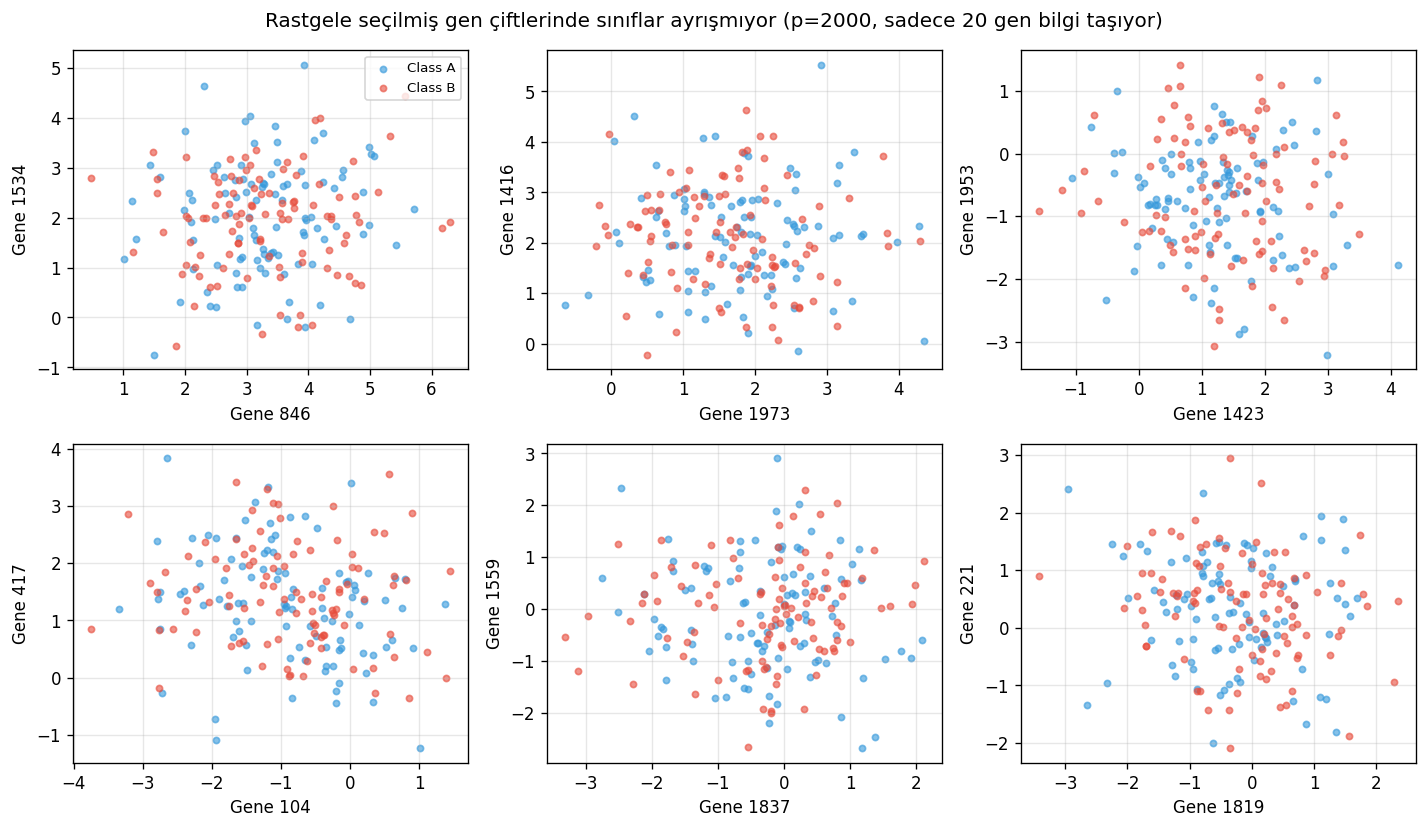

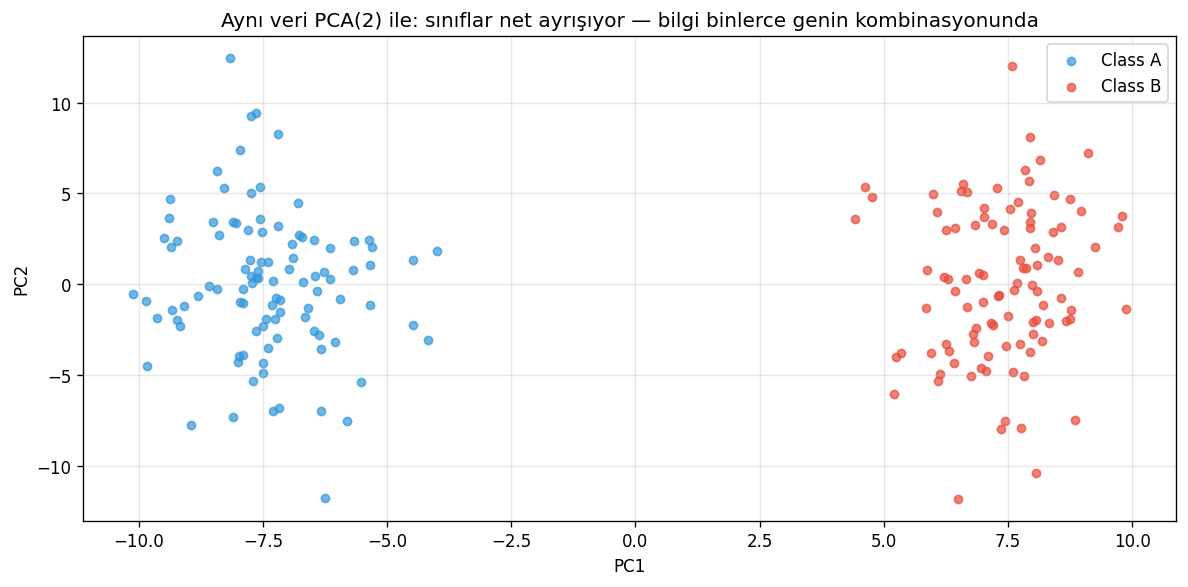

In [2]:
rng = np.random.default_rng(RANDOM_STATE)
n_per_class = 100
p_genes = 2000

mu_a = rng.normal(0, 1, p_genes)
mu_b = mu_a.copy()
informative_idx = rng.choice(p_genes, size=20, replace=False)
mu_b[informative_idx] += 3.0

X_a = rng.normal(mu_a, 1.0, (n_per_class, p_genes))
X_b = rng.normal(mu_b, 1.0, (n_per_class, p_genes))
X_demo = np.vstack([X_a, X_b])
y_demo = np.array([0] * n_per_class + [1] * n_per_class)

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax in axes.ravel():
    i, j = rng.choice(p_genes, size=2, replace=False)
    ax.scatter(X_demo[y_demo == 0, i], X_demo[y_demo == 0, j], s=14, alpha=0.6, c='#3498DB', label='Class A')
    ax.scatter(X_demo[y_demo == 1, i], X_demo[y_demo == 1, j], s=14, alpha=0.6, c='#E74C3C', label='Class B')
    ax.set_xlabel(f'Gene {i}')
    ax.set_ylabel(f'Gene {j}')

axes[0, 0].legend(loc='upper right', fontsize=8)
fig.suptitle('Rastgele seçilmiş gen çiftlerinde sınıflar ayrışmıyor (p=2000, sadece 20 gen bilgi taşıyor)')
fig.tight_layout()
plt.show()

pca_demo = PCA(n_components=2, random_state=RANDOM_STATE).fit_transform(X_demo)
fig, ax = plt.subplots(figsize=(10, 5))
ax.scatter(pca_demo[y_demo == 0, 0], pca_demo[y_demo == 0, 1], s=24, alpha=0.7, c='#3498DB', label='Class A')
ax.scatter(pca_demo[y_demo == 1, 0], pca_demo[y_demo == 1, 1], s=24, alpha=0.7, c='#E74C3C', label='Class B')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title('Aynı veri PCA(2) ile: sınıflar net ayrışıyor — bilgi binlerce genin kombinasyonunda')
ax.legend()
fig.tight_layout()
plt.show()

Üstteki ızgarada **6 rastgele gen çiftinin hiçbiri** iki sınıfı ayırt edemiyor; çünkü bilgi taşıyan 20 genin rastgele bir çifte düşme olasılığı pratikte sıfır. Alttaki tek PCA projeksiyonu ise sınıfları derhal ayırıyor — çünkü PC1, bilgi taşıyan 20 genin **lineer kombinasyonu** olarak otomatik ortaya çıkıyor. Bu, PCA'nın neden feature selection'dan üstün bir feature extraction tekniği olduğunun çıplak gözle görülebilen kanıtıdır.

## 1.2 — PCA: Bir Optimizasyon Problemi Olarak

PCA'yı tanımlamanın en temiz yolu, onu bir **varyans-maksimizasyonu** problemi olarak yazmaktır. Veri matrisimiz $X \in \mathbb{R}^{n \times p}$ olsun ve sütunları **merkezlenmiş** kabul edelim:

$$\tilde{X} = X - \mathbf{1}_n \bar{x}^\top, \quad \bar{x} = \frac{1}{n} \sum_{i=1}^{n} x_i \in \mathbb{R}^p.$$

Merkezleme şarttır; çünkü PCA, orijini geçen yönleri arar. Aksi durumda "en büyük varyans yönü" verinin ortalamasına doğru bir vektör tarafından domine edilebilir. Merkezleme sonrası **ampirik covariance matrix**:

$$S = \frac{1}{n-1} \tilde{X}^\top \tilde{X} \in \mathbb{R}^{p \times p}.$$

$S$ simetrik ve pozitif yarı-tanımlıdır (PSD), dolayısıyla **gerçek ve negatif olmayan eigenvalue**'lara ve **ortogonal eigenvector**'lere sahiptir (spektral teorem).

### Birinci Principal Component

Birinci principal component, veriyi üzerine projekte ettiğimizde **varyansı maksimize eden** birim vektördür. Bir birim vektör $v \in \mathbb{R}^p$ için projeksiyon skorları $\tilde{X} v \in \mathbb{R}^n$ ve bu skorların varyansı:

$$\mathrm{Var}(\tilde{X} v) = \frac{1}{n-1} \lVert \tilde{X} v \rVert^2 = \frac{1}{n-1} v^\top \tilde{X}^\top \tilde{X} v = v^\top S v.$$

Buradan optimizasyon problemi:

$$\boxed{\; v_1 \;=\; \arg\max_{v \in \mathbb{R}^p} \; v^\top S v \quad \text{s.t.} \quad \lVert v \rVert_2 = 1. \;}$$

Kısıt olmadan $v^\top S v$ sınırsızdır (ölçekleme ile büyütülebilir), bu yüzden $\lVert v \rVert = 1$ şarttır.

### Lagrangian ve Eigenvalue Probleminin Doğuşu

Lagrangian:

$$\mathcal{L}(v, \lambda) = v^\top S v - \lambda (v^\top v - 1).$$

Stasyoner nokta için $\nabla_v \mathcal{L} = 0$:

$$2 S v - 2 \lambda v = 0 \;\;\Longrightarrow\;\; \boxed{\; S v = \lambda v. \;}$$

Yani **stasyoner noktalar $S$'in eigenvektörleridir**. Hangi eigenvektör maksimumu verir? Hedef fonksiyonu değerlendirelim: $v^\top S v = v^\top (\lambda v) = \lambda \lVert v \rVert^2 = \lambda$. Demek ki maksimum, **en büyük eigenvalue**'ya karşılık gelen eigenvektörde elde edilir. Bu vektöre $v_1$, eigenvalue'ya $\lambda_1$ diyoruz; birinci PC'nin örnek varyansı tam olarak $\lambda_1$'dir.

### Sonraki Componentler: Sıralı Kısıtlı Maksimizasyon

$k$. principal component, **önceki tüm componentlere ortogonal** olan birim vektörler arasında varyansı maksimize eder:

$$v_k \;=\; \arg\max_{v} \; v^\top S v \quad \text{s.t.} \quad \lVert v \rVert = 1, \;\; v \perp v_1, \ldots, v_{k-1}.$$

Aynı Lagrangian argümanı ile bu, $S$'in **$k$. en büyük eigenvalue**'sina karşılık gelen eigenvektörüdür. Spektral teorem zaten farklı eigenvalue'lara ait eigenvektörlerin otomatik ortogonal olduğunu garanti eder; aynı eigenvalue'nun katlılığı varsa Gram–Schmidt ile ortogonalize edilebilir. Sonuç olarak PCA, $S$'in **tüm spektrumunu** verir:

$$S = V \Lambda V^\top, \quad V = [v_1 \mid v_2 \mid \cdots \mid v_p], \quad \Lambda = \mathrm{diag}(\lambda_1 \geq \lambda_2 \geq \cdots \geq \lambda_p \geq 0).$$

### Geometrik Yorum

$v_1, \ldots, v_p$ ortogonal bir tabandır; veriyi bu tabanda yeniden yazmak bir **rotation**'dır. PCA bilgi kaybı yapmaz — $p$ component tutarsanız orijinal veriyi mükemmel geri alırsınız. "Boyut indirgeme" sadece ilk $k$ component'i kullanıp gerisini atmaktır; bu, veriyi $v_1, \ldots, v_k$ tarafından gerilen $k$-boyutlu altuzaya **dik projeksiyon**'dur ve **rank-$k$ approximation** olarak da bilinir.

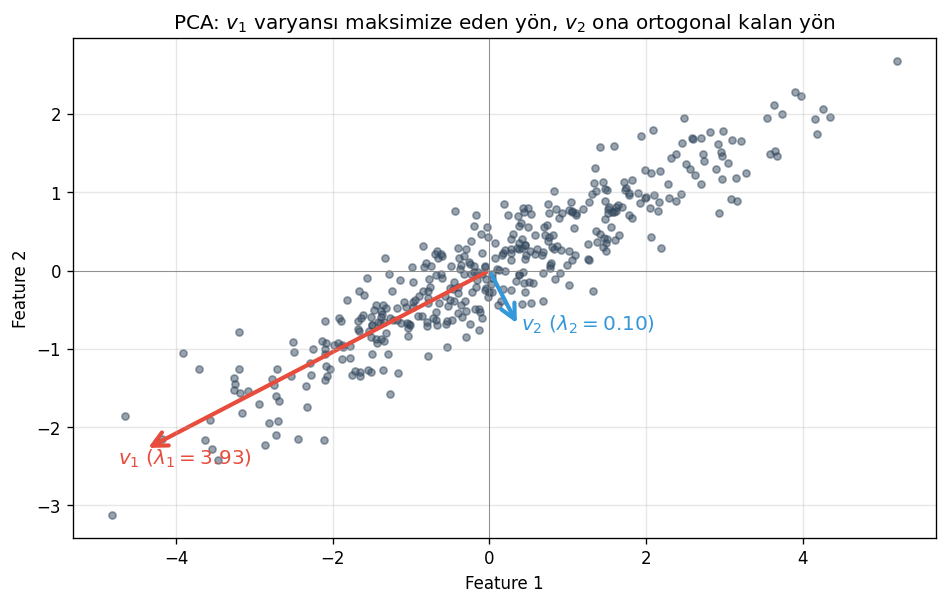

In [3]:
rng = np.random.default_rng(RANDOM_STATE)
cov_demo = np.array([[3.0, 1.6], [1.6, 1.0]])
X_2d = rng.multivariate_normal(mean=[0, 0], cov=cov_demo, size=400)

S_demo = np.cov(X_2d, rowvar=False)
eigvals_demo, eigvecs_demo = np.linalg.eigh(S_demo)
order = np.argsort(eigvals_demo)[::-1]
eigvals_demo, eigvecs_demo = eigvals_demo[order], eigvecs_demo[:, order]

fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(X_2d[:, 0], X_2d[:, 1], s=18, alpha=0.5, c='#34495E')
for i, color in zip(range(2), ['#E74C3C', '#3498DB']):
    end = eigvecs_demo[:, i] * np.sqrt(eigvals_demo[i]) * 2.5
    arrow = FancyArrowPatch((0, 0), tuple(end), arrowstyle='->', mutation_scale=22, color=color, lw=2.5)
    ax.add_patch(arrow)
    ax.text(end[0] * 1.08, end[1] * 1.08, f'$v_{i+1}$ ($\\lambda_{i+1}={eigvals_demo[i]:.2f}$)', color=color, fontsize=12)

ax.set_aspect('equal')
ax.set_xlabel('Feature 1')
ax.set_ylabel('Feature 2')
ax.set_title('PCA: $v_1$ varyansı maksimize eden yön, $v_2$ ona ortogonal kalan yön')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
fig.tight_layout()
plt.show()

Yukarıdaki 2B örnekte $v_1$, eliptik bulutun **uzun ekseni** boyunca uzanır; bu eksen üzerindeki projeksiyon varyansı $\lambda_1$'dir. $v_2$ ona ortogonaldir ve geri kalan varyansı ($\lambda_2$) taşır. Yüksek boyutta da geometri aynıdır, sadece çizilemez: PCA verinin **kovaryans elipsoidinin** ana eksenlerini bulur.

## 1.3 — SVD ile Bağlantı

PCA'yı $S$'in eigendecomposition'ı olarak tanımlamak teorik olarak temiz ama **pratikte sorunludur**: $p = 20{,}531$ için $S$ matrisi $p \times p = 20{,}531 \times 20{,}531 \approx 4.2 \cdot 10^8$ kayan-nokta hücresi içerir (yaklaşık 3 GB float64). Üstüne üstlük $S$'i hesaplarken $X^\top X$ çarpımı **conditioning sayısını kareler**, küçük singular value'lar yuvarlama hatalarında kaybolur. Bu nedenle gerçek implementasyonlar (NumPy, SciPy, scikit-learn) PCA'yı **Singular Value Decomposition (SVD)** üzerinden hesaplar.

### SVD Tanımı

Herhangi bir reel $\tilde{X} \in \mathbb{R}^{n \times p}$ matrisi için thin SVD:

$$\tilde{X} = U \Sigma V^\top, \quad U \in \mathbb{R}^{n \times r}, \;\; \Sigma \in \mathbb{R}^{r \times r}, \;\; V \in \mathbb{R}^{p \times r}, \quad r = \min(n, p).$$

Burada $U^\top U = V^\top V = I_r$ ve $\Sigma = \mathrm{diag}(\sigma_1 \geq \sigma_2 \geq \cdots \geq \sigma_r \geq 0)$.

### SVD ↔ Eigendecomposition İlişkisi

$\tilde{X} = U \Sigma V^\top$ ifadesini $S$'in tanımına koyalım:

$$S = \frac{1}{n-1} \tilde{X}^\top \tilde{X} = \frac{1}{n-1} (V \Sigma U^\top)(U \Sigma V^\top) = V \left( \frac{\Sigma^2}{n-1} \right) V^\top.$$

Bu ifadeyi $S = V \Lambda V^\top$ ile karşılaştırınca:

$$\boxed{\; \lambda_k = \frac{\sigma_k^2}{n-1}, \quad v_k = V_{:,k}. \;}$$

Yani **principal component'ler $\tilde{X}$'in sağ singular vektörleridir** ve eigenvalue'lar singular value'ların karelerinin $(n-1)$'e bölünmüş halidir. PC skorları için ek bir kimlik:

$$\tilde{X} V = U \Sigma \;\;\Longrightarrow\;\; \text{skorlar} = U \Sigma.$$

### Neden SVD Daha İyi?

1. **Numerik kararlılık.** Eigendecomposition için $\tilde{X}^\top \tilde{X}$ inşa etmek conditioning sayısını $\kappa(\tilde{X})^2$'ye yükseltir. SVD doğrudan $\tilde{X}$ üzerinde çalıştığı için $\kappa(\tilde{X})$ ile sınırlıdır — özellikle yakın-tekil veride çok daha güvenlidir.
2. **$p \gg n$ verimliliği.** $S \in \mathbb{R}^{p \times p}$ matrisini kurmak $\mathcal{O}(np^2)$ zaman ve $\mathcal{O}(p^2)$ bellek ister; ancak $\tilde{X}$ matrisinin SVD'si $\mathcal{O}(\min(n,p)^2 \cdot \max(n,p))$ zamanda hesaplanır. TCGA için $n=801, p=20531$:
   - Eigendecomposition: $\mathcal{O}(801 \cdot 20531^2) \approx 3.4 \cdot 10^{11}$
   - SVD: $\mathcal{O}(801^2 \cdot 20531) \approx 1.3 \cdot 10^{10}$

   Yaklaşık **25 kat hız farkı** ve **kuadratik bellek tasarrufu** (yaklaşık 3 GB yerine birkaç yüz MB).
3. **Truncated/randomized SVD.** Sadece en büyük $k$ singular value'ya ihtiyacımız varsa, randomized SVD $\mathcal{O}(np k)$ zamanda iş bitirir. sklearn'ün `PCA(svd_solver='randomized')` seçeneği tam olarak bunu yapar — TCGA gibi gen ekspresyon matrislerinde varsayılan tercihtir.

### Sınıfta İşlenmeyen Pratik İpucu

$p \gg n$ durumunda $X^\top X$ yerine **$X X^\top \in \mathbb{R}^{n \times n}$** (Gram matrisi) üzerinden eigendecomposition yapmak da bir alternatif: bu çok daha küçük matrisin eigenvectorleri $U$'yu verir; $V$ ise $V = \tfrac{1}{\sigma_k} \tilde{X}^\top u_k$ formülüyle yeniden inşa edilir. Bu trick, scikit-learn'ün eski sürümlerinde **dual PCA** olarak yer alıyordu ve hâlâ kernel PCA'nın özüdür.

## 1.4 — Açıklanan Varyans Oranı

PCA bir dizi yeni eksen üretir; sonraki soru: bunlardan **kaçını tutmalıyız**? Cevap, her bir bileşenin verideki toplam varyansın ne kadarını yakaladığına bakmakla başlar.

### Toplam Varyans = İz

Verideki toplam varyans, her özelliğin varyansının toplamıdır; bu ise $S$'in iz'idir:

$$\mathrm{TotalVar}(X) = \sum_{j=1}^{p} \mathrm{Var}(X_{:,j}) = \mathrm{tr}(S) = \sum_{k=1}^{p} \lambda_k.$$

Son eşitlik spektral teoremin doğrudan sonucudur: iz, eigenvalue'ların toplamına eşittir. Yani **eigenvalue'lar verinin varyansını parsellerler**.

### Proportion of Variance Explained (PVE)

$k$. principal component'in açıkladığı varyans oranı:

$$\boxed{\; \mathrm{PVE}_k = \frac{\lambda_k}{\sum_{j=1}^{p} \lambda_j}. \;}$$

Kümülatif PVE:

$$\mathrm{CumPVE}(k) = \sum_{i=1}^{k} \mathrm{PVE}_i = \frac{\sum_{i=1}^{k} \lambda_i}{\sum_{j=1}^{p} \lambda_j}.$$

Pratik kural: ilk $k$ bileşeni toplam varyansın **%80–%95** arasını açıklayacak şekilde seçmek. Hedef oran uygulama alanına bağlıdır — görselleştirme için $k = 2$ veya $3$ zorunludur (varyans az olsa bile), ama downstream supervised model için kümülatif PVE eşik olarak kullanılır.

### Scree Plot ve "Dirsek" Kuralı

**Scree plot**: $k$'ya karşı $\lambda_k$ (veya $\mathrm{PVE}_k$) çubuğu. Tipik şekil: hızlıca düşen ilk birkaç değer, ardından **uzun bir düz kuyruk**. Düz kısma giriş noktasındaki "dirsek" (elbow), sinyalin gürültüden ayrıldığı yer olarak yorumlanır.

### Kaiser Kriteri vs. Kırılma Noktası

İki popüler eşik kuralı:

| Kural | Tanım | Avantaj | Dezavantaj |
| --- | --- | --- | --- |
| **Kaiser** | $\lambda_k > 1$ olan tüm $k$'leri tut (correlation PCA için) | Otomatik, parametresiz | Genellikle çok az veya çok fazla bileşen seçer; teorik temeli zayıf |
| **Elbow** | Scree plot'ta eğimin değiştiği noktaya kadar tut | Veri-spesifik, dirseği görsel olarak ayırt etmek kolaydır | Sübjektif, kıvrım keskin değilse belirsiz |
| **Kümülatif PVE eşiği** | $\mathrm{CumPVE}(k) \geq 0.90$ olan en küçük $k$ | Yorumlanabilir, raporlanabilir | Eşik (%80, %90, %95) keyfi |

Pratikte üçünü birden raporlamak ve **downstream görev performansıyla** (örneğin bu projede KNN cross-validation accuracy) doğrulamak en sağlam yaklaşımdır. Bölüm 3.6 ve 4.4'te tam olarak bunu yapacağız.

## 1.5 — Covariance PCA vs. Correlation PCA

PCA'yı uygulamadan önce verinin **standardize edilip edilmeyeceği** kritik bir karardır ve uygulamada iki farklı PCA türü ortaya çıkarır:

- **Covariance PCA** — sadece merkezlenmiş veri üzerinde çalışır:
  $$\tilde{X}_{ij} = X_{ij} - \bar{X}_{:,j}, \quad S_{\text{cov}} = \frac{1}{n-1} \tilde{X}^\top \tilde{X}.$$
  Özelliklerin **orijinal birimleri ve ölçekleri korunur**. Büyük varyanslı özellikler eigendecomposition'a daha çok katkıda bulunur.
- **Correlation PCA** — merkezleme + birim varyansa ölçekleme yapılır:
  $$Z_{ij} = \frac{X_{ij} - \bar{X}_{:,j}}{\hat{\sigma}_j}, \quad S_{\text{cor}} = \frac{1}{n-1} Z^\top Z.$$
  Her özellik varyans olarak eşitlenir; sonuç $S_{\text{cor}}$ ise tam olarak orijinal $X$'in **correlation matrix**'idir, diyagonali tüm 1'lerden oluşur.

### Karar Kriteri Tablosu

| Soru | Covariance PCA | Correlation PCA |
| --- | --- | --- |
| Tüm özellikler aynı birimde mi? | Evet → tercih | Hayır → kullanma |
| Özellik varyansları **biyolojik anlam** taşıyor mu? | Evet → tercih (varyans bilgidir) | Hayır → daha az risk |
| Özellikler farklı birimlerde mi (m, kg, °C, ...)? | Hayır → birimce büyük olan domine eder | Evet → tercih (birim-bağımsız) |
| Outlier'lara duyarlılık? | Yüksek (varyans karesel) | Yüksek (z-skor de outlier'a duyarlı) |
| sklearn karşılığı | `PCA().fit(X)` | `PCA().fit(StandardScaler().fit_transform(X))` |

### Gene Expression için Hangisi?

RNA-seq verisinde tüm gen değerleri **aynı birimde** ölçülür (typically log-normalized RPKM/TPM veya FPKM). Üstelik gen varyansındaki farklılıklar **biyolojik bilgi taşır**: housekeeping gen düşük varyanslı, marker gen yüksek varyanslı olur. Correlation PCA bu bilgiyi siler ve her geni eşit ağırlıkla muamele eder, bu da genellikle istemediğimiz bir şeydir. Sonuç olarak **gene expression için varsayılan tercih covariance PCA**'dır.

### WDBC için Hangisi?

WDBC'de özellikler farklı doğaya sahip: `area_mean` (yüzlerce piksel²) ile `smoothness_mean` (0–1 arası oran) aynı ölçekte değil. Bu durumda **correlation PCA daha güvenli varsayılan tercihtir**, aksi takdirde `area_mean` PC1'i tek başına şekillendirebilir. Bölüm 4'te her ikisini de uygulayıp sayısal olarak göstereceğiz.

### Matematiksel Fark — Ne Değişiyor?

Standardizasyon, $\tilde{X}$'i $Z = \tilde{X} D^{-1}$ ile çarpmaktır ($D = \mathrm{diag}(\hat{\sigma}_1, \ldots, \hat{\sigma}_p)$). Bu, **bir özellik-uzayında lineer dönüşüm**dür; ne bir rotation ne de bir öteleme. Sonuçta eigenvektörler de eigenvalue'lar da değişir; iki yöntemin sonuçları **birbirinden basit bir formülle elde edilemez**. Yani "hangisini kullanacağız" sorusunun cevabı tamamen veriyi nasıl yorumladığımıza bağlıdır.

### Bölüm 1 Özeti

Şu noktada elimizde PCA için tam bir matematiksel sözlük var:

1. **Problem**: $p \gg n$ olan biyolojik verinin görselleştirilemez ve gürültülü yapısı.
2. **Formülasyon**: $v_1 = \arg\max_{\lVert v \rVert = 1} v^\top S v$, Lagrangian ile eigenvalue problemine eşdeğer.
3. **Hesaplama**: $\tilde{X}$ üzerinde SVD; $\lambda_k = \sigma_k^2 / (n-1)$, skorlar $U \Sigma$.
4. **Yorum**: PVE ve cumulative PVE; scree plot ile bileşen sayısını seçme.
5. **Önişleme tercihi**: gene expression için covariance, heterojen klinik özellikler için correlation PCA.

Sonraki bölümde bu denklemleri NumPy ile **sıfırdan** yazıp `sklearn.decomposition.PCA` ile karşılaştıracağız.

# Bölüm 2 — PCA Sıfırdan: NumPy İmplementasyonu

Önceki notebook'taki matematik bizi şu reçeteye götürdü:

1. Veriyi merkezle: $\tilde{X} = X - \bar{x}$.
2. Kovaryans matrisini hesapla: $S = \tfrac{1}{n-1} \tilde{X}^\top \tilde{X}$.
3. $S$'in eigendecomposition'ını yap: $S = V \Lambda V^\top$.
4. Eigenvalue'ları azalan sıraya koy; ilk $k$ eigenvector PC eksenlerini, eigenvalue'lar ise varyansları verir.
5. Skorlar: $T = \tilde{X} V_{:, :k}$.

Şimdi bu reçeteyi adım adım koda dökeceğiz.

## 2.1 — PCA From Scratch

API'yi `sklearn.decomposition.PCA` ile uyumlu tutuyoruz: `fit`, `transform`, `fit_transform` metodları ve `components_`, `explained_variance_`, `explained_variance_ratio_`, `mean_` fitted-attribute'ları. Eigendecomposition için `np.linalg.eigh` kullanıyoruz; `eigh` simetrik matrisler için optimize edilmiş ve **gerçek eigenvalue'ları artan sırada** döndürür — biz de bu çıktıyı tersine çevirip azalan sıraya koyacağız.

Önemli uygulama detayı: `eigh`, simetrik matriste sayısal olarak kararlıdır; `eig` ise genel matrisler için tasarlandığından küçük sanal kısımlar dönebilir. Kovaryans matrisi simetrik olduğu için **her zaman `eigh` kullanılmalıdır**.

In [4]:
class PCAFromScratch:
    """PCA via eigendecomposition of the sample covariance matrix."""

    def __init__(self, n_components):
        self.n_components = n_components

    def fit(self, X):
        """Estimate principal axes from centered covariance matrix."""
        X = np.asarray(X, dtype=np.float64)
        n_samples = X.shape[0]
        self.mean_ = X.mean(axis=0)
        X_centered = X - self.mean_
        S = (X_centered.T @ X_centered) / (n_samples - 1)
        eigvals, eigvecs = np.linalg.eigh(S)
        order = np.argsort(eigvals)[::-1]
        eigvals = eigvals[order]
        eigvecs = eigvecs[:, order]
        self._total_variance = eigvals.sum()
        self.explained_variance_ = eigvals[: self.n_components]
        self.components_ = eigvecs[:, : self.n_components].T
        return self

    def transform(self, X):
        """Project centered data onto the learned principal axes."""
        return (np.asarray(X, dtype=np.float64) - self.mean_) @ self.components_.T

    def fit_transform(self, X):
        """Convenience: fit and return scores in a single call."""
        return self.fit(X).transform(X)

    @property
    def explained_variance_ratio_(self):
        """Fraction of total variance carried by each retained component."""
        return self.explained_variance_ / self._total_variance

## 2.2 — Sklearn ile Karşılaştırma, İşaret Belirsizliği ve Hız

İmplementasyonun doğruluğu üç düzeyde test edilmektedir: (i) `explained_variance_ratio_` değerleri makine epsilon mertebesinde aynı olmalıdır, (ii) skorlar **işarete kadar** eşleşmelidir (Eigenvector belirsizliği), (iii) altuzaylar aynı olduğu için reconstruction birebir aynı olmalıdır. Ayrıca farklı $n, p$ rejimlerinde hız karşılaştırması yapılmaktadır.


### Sklearn ile Birebir Karşılaştırma

İmplementasyonumuzun doğruluğunu üç düzeyde kontrol edeceğiz:

1. **`explained_variance_ratio_`** birebir aynı olmalı (yüzdelik PVE değerleri).
2. **Skorlar** birebir aynı olmalı — fakat **eigenvector'ler işarete kadar tekildir** (eğer $v_k$ bir eigenvector ise $-v_k$ de aynı eigenvalue'ya ait bir eigenvector'dür). İki implementasyon farklı işaret seçebilir; bu durumda skorların **mutlak değerleri** çakışmalıdır.
3. **Reconstruction** birebir aynı olmalı — çünkü iki tarafın yarattığı altuzaylar aynıdır; sadece bu altuzayı geren tabanların yönü değişebilir, ama izdüşüm aynıdır.

Karşılaştırmayı küçük ve kontrollü bir sentetik veri üzerinde yapıyoruz; iki implementasyon $p \ll n$ rejiminde eşit hızlı çalışır, sayısal hassasiyet karşılaştırması yapmak için ideal.

In [5]:
rng = np.random.default_rng(RANDOM_STATE)
n_demo, p_demo, k_demo = 300, 50, 5
X_demo = rng.normal(size=(n_demo, p_demo))
X_demo[:, 0] *= 6.0
X_demo[:, 1] *= 3.0
X_demo[:, 2] *= 2.0

pca_ours = PCAFromScratch(n_components=k_demo).fit(X_demo)
pca_skl = PCA(n_components=k_demo, random_state=RANDOM_STATE).fit(X_demo)

scores_ours = pca_ours.transform(X_demo)
scores_skl = pca_skl.transform(X_demo)

ratio_diff = np.max(np.abs(pca_ours.explained_variance_ratio_ - pca_skl.explained_variance_ratio_))
abs_score_diff = np.max(np.abs(np.abs(scores_ours) - np.abs(scores_skl)))
raw_score_diff = np.max(np.abs(scores_ours - scores_skl))

print(f'Explained variance ratio — max abs difference: {ratio_diff:.2e}')
print(f'Scores             — max raw difference     : {raw_score_diff:.2e}')
print(f'|Scores|           — max difference         : {abs_score_diff:.2e}')

print('\nPVE comparison:')
comparison_df = pd.DataFrame({
    'PC': np.arange(1, k_demo + 1),
    'PCAFromScratch_pve': pca_ours.explained_variance_ratio_,
    'sklearn_pve': pca_skl.explained_variance_ratio_,
})
print(comparison_df.to_string(index=False))

Explained variance ratio — max abs difference: 3.33e-16
Scores             — max raw difference     : 2.03e+01
|Scores|           — max difference         : 3.29e-13

PVE comparison:
 PC  PCAFromScratch_pve  sklearn_pve
  1            0.345986     0.345986
  2            0.100621     0.100621
  3            0.043373     0.043373
  4            0.020538     0.020538
  5            0.019192     0.019192


### İşaret Belirsizliği — Neden ve Nasıl Tespit Edilir?

$Sv = \lambda v$ denklemini sağlayan her $v$ için $-v$ de aynı denklemi sağlar; çünkü $S(-v) = -Sv = -\lambda v = \lambda(-v)$. Yani **eigenvektörler işarete kadar belirlidir** (eigenvalue katlılığı yoksa). Pratikte LAPACK rutinleri (NumPy ve scikit-learn'ün ikisi de aynı altyapıyı kullanır) sayısal kararlılığa göre bir işaret seçer; iki bağımsız çağrı arasında işaret farklı çıkabilir.

Sonuç olarak scores matrisi sütun bazında **±1 ile çarpılmış** olabilir. Aşağıdaki kontrol bunu sayısal olarak gösteriyor: her PC için skorların oranı ya $+1$ ya da $-1$ olmalı.

In [6]:
sign_pattern = np.sign(scores_skl[0] / scores_ours[0])
scores_ours_aligned = scores_ours * sign_pattern

aligned_diff = np.max(np.abs(scores_ours_aligned - scores_skl))
print(f'Per-PC sign vector (sklearn / ours): {sign_pattern}')
print(f'Aligned max abs difference         : {aligned_diff:.2e}')
print('-> İşaret düzeltmesinden sonra skorlar makine epsilon mertebesinde eşittir.')

Per-PC sign vector (sklearn / ours): [ 1. -1.  1. -1.  1.]
Aligned max abs difference         : 3.29e-13
-> İşaret düzeltmesinden sonra skorlar makine epsilon mertebesinde eşittir.


### Hız Karşılaştırması

İki implementasyon küçük $p$ için neredeyse aynı zamanda çalışır; çünkü her iki taraf da LAPACK'a düşer (`eigh` vs `svd`). Asimptotik fark $p \gg n$ rejiminde belirir: scikit-learn varsayılan olarak `'auto'` solver kullanır ve yüksek boyutta SVD'ye/randomized'a otomatik geçer; bizim implementasyonumuz ise her zaman $p \times p$ kovaryans matrisini açıkça kurar.

In [7]:
def benchmark(fn, *args, repeats=5):
    """Run fn(*args) repeats times and return mean elapsed seconds."""
    durations = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        fn(*args)
        durations.append(time.perf_counter() - t0)
    return np.mean(durations), np.std(durations)

configs = [(500, 100), (500, 500), (300, 2000)]
rows = []
for n, p in configs:
    X_bench = rng.normal(size=(n, p))
    mean_ours, std_ours = benchmark(lambda X: PCAFromScratch(n_components=5).fit_transform(X), X_bench)
    mean_skl, std_skl = benchmark(lambda X: PCA(n_components=5, random_state=RANDOM_STATE).fit_transform(X), X_bench)
    rows.append({
        'n': n,
        'p': p,
        'PCAFromScratch (s)': f'{mean_ours:.3f} ± {std_ours:.3f}',
        'sklearn (s)': f'{mean_skl:.3f} ± {std_skl:.3f}',
        'ratio (ours / skl)': f'{mean_ours / mean_skl:.2f}x',
    })

timing_df = pd.DataFrame(rows)
print(timing_df.to_string(index=False))

  n    p PCAFromScratch (s)   sklearn (s) ratio (ours / skl)
500  100      0.005 ± 0.000 0.041 ± 0.003              0.12x
500  500      0.140 ± 0.010 0.179 ± 0.015              0.78x
300 2000      1.767 ± 0.111 0.047 ± 0.009             37.64x


$p$ büyüdükçe oran lehimize bozulur — bu beklenen sonuçtur. Bizim implementasyonumuz $\mathcal{O}(p^2)$ bellek ve $\mathcal{O}(np^2)$ zamana ihtiyaç duyar (covariance matrix oluşturma + $p \times p$ eigendecomp). scikit-learn ise $p \gg n$ olduğunda otomatik olarak SVD'ye geçer ve $\mathcal{O}(np \cdot k)$ ile yetinir. TCGA gibi $p = 20{,}531$ veri setinde **kendi implementasyonumuzu doğrudan çalıştırmak pratik değildir** — bu yüzden Bölüm 3'ten itibaren sklearn kullanacağız. PCAFromScratch'i "motorun nasıl çalıştığını biliyoruz" kanıtı olarak ceremoni-niteliğinde elimizde tutuyoruz.

## 2.3 — Reconstruction ve Hata Analizi

PCA'nın ikinci yorumu: ilk $k$ principal component, veriyi $k$-boyutlu altuzaya en iyi **en küçük kareler anlamında** projekte eden lineer haritadır (Eckart–Young–Mirsky teoremi).

İlk $k$ component ile rekonstrüksiyon:

$$\hat{X}^{(k)} = \bar{x} + T_{:, :k} \, V_{:, :k}^\top, \quad T = \tilde{X} V.$$

Normalleştirilmiş **reconstruction error** (Frobenius karesi olarak):

$$\mathrm{ReconErr}(k) = \frac{\lVert X - \hat{X}^{(k)} \rVert_F^2}{\lVert \tilde{X} \rVert_F^2} = \frac{\sum_{j > k} \lambda_j}{\sum_{j} \lambda_j} = 1 - \mathrm{CumPVE}(k).$$

Yani reconstruction error ile cumulative PVE **birebir tamamlayıcıdır**. Bu, az önce ispatladığımız şeyin pratik manifestasyonudur: PCA'nın "varyansı maksimize etme" formülasyonu, "reconstruction error'ı minimize etme" formülasyonuna matematiksel olarak eşdeğerdir.

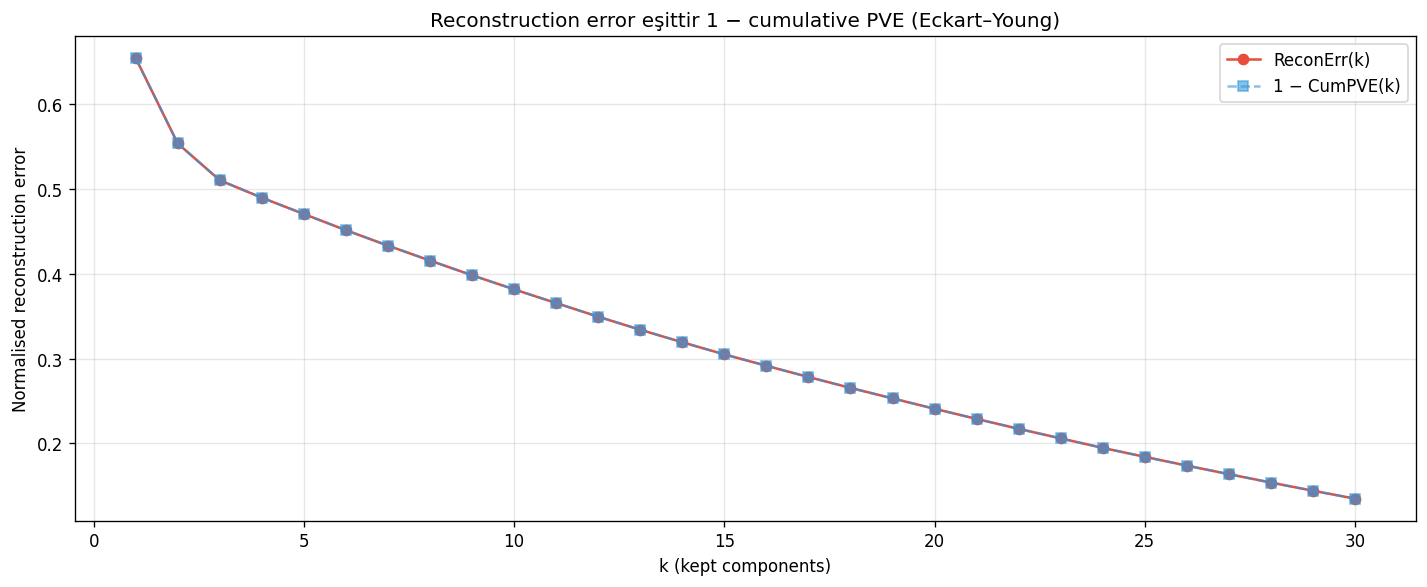


ReconErr(k) − (1 − CumPVE(k)) maksimum sapması: 4.44e-16


In [8]:
def reconstruction_error_curve(X, max_k):
    """Return per-k normalised Frobenius reconstruction error of X using its leading PCs."""
    X = np.asarray(X, dtype=np.float64)
    pca = PCA(n_components=max_k, random_state=RANDOM_STATE).fit(X)
    mean = pca.mean_
    V = pca.components_
    T = pca.transform(X)
    centered = X - mean
    denom = np.linalg.norm(centered, 'fro') ** 2
    errors = np.empty(max_k)
    for k in range(1, max_k + 1):
        X_hat_k = mean + T[:, :k] @ V[:k, :]
        errors[k - 1] = np.linalg.norm(X - X_hat_k, 'fro') ** 2 / denom
    pve = pca.explained_variance_ratio_
    return errors, pve

max_k_recon = 30
errors_demo, pve_demo = reconstruction_error_curve(X_demo, max_k_recon)
cumpve_demo = np.cumsum(pve_demo)

fig, ax = plt.subplots(figsize=(12, 5))
ks_axis = np.arange(1, max_k_recon + 1)
ax.plot(ks_axis, errors_demo, 'o-', color='#E74C3C', label='ReconErr(k)')
ax.plot(ks_axis, 1 - cumpve_demo, 's--', color='#3498DB', alpha=0.6, label='1 − CumPVE(k)')
ax.set_xlabel('k (kept components)')
ax.set_ylabel('Normalised reconstruction error')
ax.set_title('Reconstruction error eşittir 1 − cumulative PVE (Eckart–Young)')
ax.legend()
fig.tight_layout()
plt.show()

identity_diff = np.max(np.abs(errors_demo - (1 - cumpve_demo)))
print(f'\nReconErr(k) − (1 − CumPVE(k)) maksimum sapması: {identity_diff:.2e}')

### SVD ile Reconstruction Error'ın Türetilmesi (Eckart–Young–Mirsky)

Yukarıdaki sayısal eşitliğin matematiksel kanıtı doğrudan SVD'den izlemektedir. $\tilde{X} \in \mathbb{R}^{n \times p}$'in thin SVD'si $\tilde{X} = U \Sigma V^\top$ olsun ve rank-$k$ Approximation $\hat{X}^{(k)} = U_k \Sigma_k V_k^\top$ ile tanımlansın (burada $U_k \in \mathbb{R}^{n \times k}$, $\Sigma_k \in \mathbb{R}^{k \times k}$, $V_k \in \mathbb{R}^{p \times k}$ ilk $k$ singular bileşeni temsil eder). O zaman:

$$\lVert \tilde{X} - \hat{X}^{(k)} \rVert_F^2 \;=\; \lVert U \Sigma V^\top - U_k \Sigma_k V_k^\top \rVert_F^2 \;=\; \lVert U_{>k}\, \Sigma_{>k}\, V_{>k}^\top \rVert_F^2.$$

$U$ ve $V$ ortonormal sütunlara sahip olduğu için Frobenius normu unitary dönüşümler altında değişmez ve sadece $\Sigma$ üzerinde toplanır:

$$\lVert U_{>k}\, \Sigma_{>k}\, V_{>k}^\top \rVert_F^2 \;=\; \sum_{i > k} \sigma_i^2 \;=\; (n-1) \sum_{i > k} \lambda_i,$$

burada Bölüm 1.3'te türetilen $\lambda_i = \sigma_i^2 / (n-1)$ özdeşliği kullanılmaktadır. Paydadaki normalleştirme $\lVert \tilde{X} \rVert_F^2 = \sum_i \sigma_i^2 = (n-1) \sum_i \lambda_i$ ile bölündüğünde:

$$\boxed{\; \mathrm{ReconErr}(k) \;=\; \frac{\sum_{i > k} \lambda_i}{\sum_i \lambda_i} \;=\; 1 - \mathrm{CumPVE}(k). \;}$$

Bu özdeşlik, bir önceki kod hücresindeki sayısal kontrolün ($\mathrm{ReconErr}(k) - (1 - \mathrm{CumPVE}(k))$ farkının makine epsilonu mertebesinde sıfır çıkması) **kapalı-form ispatıdır**: PCA'nın "varyansı maksimize etme" formülasyonu, Frobenius norm anlamında "Reconstruction Error'ı minimize etme" formülasyonuna birebir eşdeğerdir.


## 2.4 — Yardımcı Fonksiyonlar

Aşağıdaki dört fonksiyon, bu notebook'un geri kalanında — Bölüm 3 (TCGA), Bölüm 4 (WDBC) ve Bölüm 5 (karşılaştırmalı analiz) — kullanılacaktır. Tek bir yerde tanımlı olmaları, tüm downstream görselleştirmelerin tutarlı renk, eksen ve format kullanmasını garanti eder. `plot_scree` fonksiyonu hem bireysel hem de Cumulative PVE eğrilerini iki ayrı `y` ekseninde gösterir ve her iki eksen için legend etiketleri sağlar.


In [9]:
def plot_pca_2d(scores, labels, color_dict, title, pc_x=1, pc_y=2, pve=None):
    """Plot 2D PCA projection with labeled groups."""
    fig, ax = plt.subplots(figsize=(10, 8))
    labels = np.asarray(labels)
    for label, color in color_dict.items():
        mask = labels == label
        if not mask.any():
            continue
        ax.scatter(scores[mask, pc_x - 1], scores[mask, pc_y - 1],
                   c=color, label=label, alpha=0.75, s=32,
                   edgecolor='white', linewidth=0.4)
    xl = f'PC{pc_x}' + (f' ({pve[pc_x - 1] * 100:.1f}% var)' if pve is not None else '')
    yl = f'PC{pc_y}' + (f' ({pve[pc_y - 1] * 100:.1f}% var)' if pve is not None else '')
    ax.set_xlabel(xl)
    ax.set_ylabel(yl)
    ax.set_title(title)
    ax.legend(title='Class', loc='best', framealpha=0.9)
    fig.tight_layout()
    return fig, ax


def plot_scree(pca_model, n_components=20, title='Scree Plot'):
    """Plot eigenvalue bar chart with cumulative variance line and dual legends."""
    pve = np.asarray(pca_model.explained_variance_ratio_)[:n_components]
    cum = np.cumsum(pve)
    x = np.arange(1, len(pve) + 1)
    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.bar(x, pve * 100, color='#3498DB', alpha=0.75, label='Individual PVE')
    ax1.set_xlabel('Component')
    ax1.set_ylabel('Individual PVE (%)', color='#3498DB')
    ax1.tick_params(axis='y', labelcolor='#3498DB')
    ax1.set_xticks(x)
    ax2 = ax1.twinx()
    ax2.plot(x, cum * 100, color='#E74C3C', marker='o', label='Cumulative PVE')
    ax2.set_ylabel('Cumulative PVE (%)', color='#E74C3C')
    ax2.tick_params(axis='y', labelcolor='#E74C3C')
    ax2.set_ylim(0, 105)
    ax2.axhline(80, ls='--', color='gray', alpha=0.5)
    ax2.axhline(90, ls='--', color='gray', alpha=0.5)
    ax1.set_title(title)
    ax1.legend(loc='upper left', framealpha=0.9)
    ax2.legend(loc='center right', framealpha=0.9)
    fig.tight_layout()
    return fig


def plot_loadings(components, feature_names, pc_index=1, top_n=20):
    """Plot top_n absolute loadings for a given principal component."""
    pc = np.asarray(components[pc_index - 1])
    feature_names = np.asarray(feature_names)
    top_idx = np.argsort(np.abs(pc))[::-1][:top_n]
    values = pc[top_idx]
    names = feature_names[top_idx]
    colors = ['#E74C3C' if v < 0 else '#2ECC71' for v in values]
    fig, ax = plt.subplots(figsize=(10, 8))
    y_pos = np.arange(len(values))
    ax.barh(y_pos, values, color=colors)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(names)
    ax.invert_yaxis()
    ax.axvline(0, color='black', lw=0.6)
    ax.set_xlabel('Loading value')
    ax.set_title(f'Top-{top_n} loadings for PC{pc_index} (green: positive, red: negative)')
    fig.tight_layout()
    return fig


def knn_accuracy_vs_components(X, y, ks, cv=5, n_neighbors=5, scale=False):
    """Return DataFrame of k -> cross-validated KNN accuracy on PCA-reduced X."""
    rows = []
    X_in = StandardScaler().fit_transform(X) if scale else np.asarray(X, dtype=np.float64)
    for k in ks:
        pca_k = PCA(n_components=k, random_state=RANDOM_STATE)
        X_k = pca_k.fit_transform(X_in)
        clf = KNeighborsClassifier(n_neighbors=n_neighbors)
        scores_cv = cross_val_score(clf, X_k, y, cv=cv, n_jobs=-1)
        rows.append({
            'n_components': k,
            'accuracy_mean': scores_cv.mean(),
            'accuracy_std': scores_cv.std(),
        })
    return pd.DataFrame(rows)


# Bölüm 3 — Dataset 1: TCGA-PANCAN Gene Expression

TCGA (The Cancer Genome Atlas), 11.000'i aşkın tümör örneğinin moleküler profillerini içeren bir uluslararası araştırma konsorsiyumudur. Bu projede UCI Machine Learning Repository üzerinden dağıtılan **PANCAN-HiSeq** alt kümesini kullanıyoruz:

- **Örnek sayısı:** $n = 801$
- **Özellik (gen) sayısı:** $p = 20{,}531$ — Illumina HiSeq RNA-seq platformundan elde edilmiş log-normalize edilmiş gen ekspresyon değerleri.
- **Sınıflar:** 5 farklı kanser tipi — **BRCA** (göğüs), **COAD** (kolon), **KIRC** (böbrek), **LUAD** (akciğer adenokarsinom), **PRAD** (prostat).

PCA için ideal bir test ortamı: $p / n \approx 25$, dolayısıyla $p \gg n$ rejimi tartışmasız.

## 3.1 — Veri Yükleme ve Keşifsel Analiz (EDA)

Veri iki ayrı CSV dosyasında: `data.csv` (özellikler) ve `labels.csv` (etiketler). İlk sütun her ikisinde de `sample_<i>` formatında bir örnek kimliği; bu yüzden onu indeks olarak yüklüyoruz.

In [10]:
tcga_data = pd.read_csv(TCGA_DATA_PATH, index_col=0)
tcga_labels = pd.read_csv(TCGA_LABELS_PATH, index_col=0)

tcga_data = tcga_data.loc[tcga_labels.index]

print(f'Expression matrix shape : {tcga_data.shape}')
print(f'Labels shape            : {tcga_labels.shape}')
print(f'Label column            : {tcga_labels.columns.tolist()}')
print(f'Sample dtype of features: {tcga_data.dtypes.unique()}')
print(f'Total NaN cells         : {tcga_data.isna().sum().sum()}')
print(f'Total NaN in labels     : {tcga_labels.isna().sum().sum()}')
tcga_data.iloc[:5, :6]

Expression matrix shape : (801, 20531)
Labels shape            : (801, 1)
Label column            : ['Class']
Sample dtype of features: [dtype('float64')]
Total NaN cells         : 0
Total NaN in labels     : 0


,gene_0,gene_1,gene_2,gene_3,gene_4,gene_5
sample_0,0.0,2.017209,3.265527,5.478487,10.431999,0.0
sample_1,0.0,0.592732,1.588421,7.586157,9.623011,0.0
sample_2,0.0,3.511759,4.327199,6.881787,9.870730,0.0
sample_3,0.0,3.663618,4.507649,6.659068,10.196184,0.0
sample_4,0.0,2.655741,2.821547,6.539454,9.738265,0.0


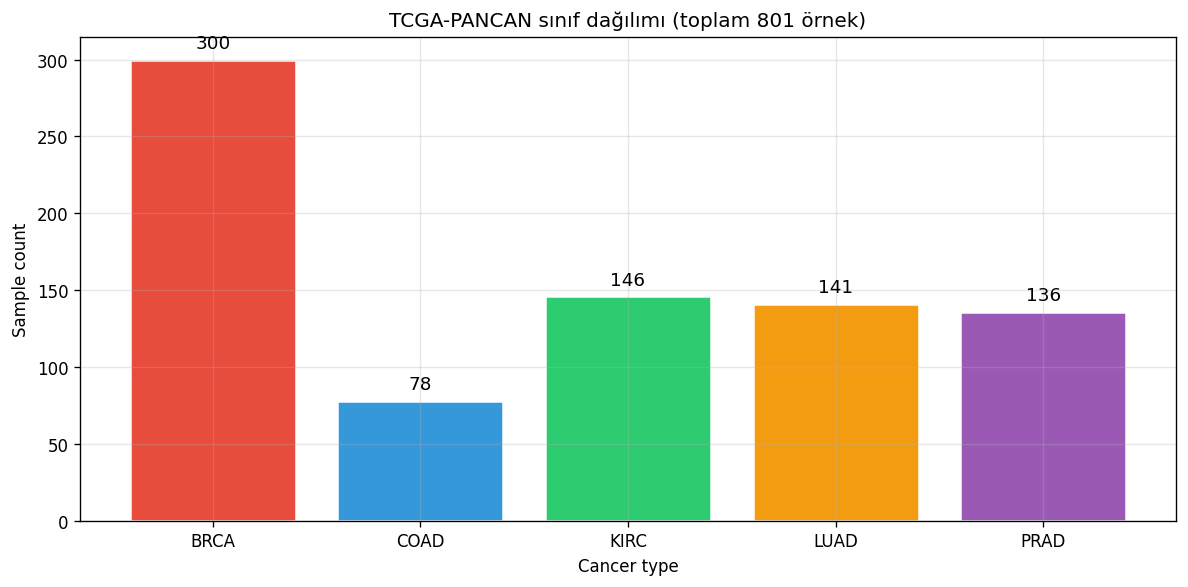


Class counts:
Class
BRCA    300
COAD     78
KIRC    146
LUAD    141
PRAD    136
Name: count, dtype: int64

Class imbalance ratio (max/min): 3.85


In [11]:
class_counts = tcga_labels['Class'].value_counts().reindex(list(CANCER_COLORS.keys()))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(class_counts.index, class_counts.values,
              color=[CANCER_COLORS[c] for c in class_counts.index],
              edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, class_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f'{count}', ha='center', va='bottom', fontsize=11)
ax.set_xlabel('Cancer type')
ax.set_ylabel('Sample count')
ax.set_title(f'TCGA-PANCAN sınıf dağılımı (toplam {class_counts.sum()} örnek)')
fig.tight_layout()
plt.show()

print('\nClass counts:')
print(class_counts)
print(f'\nClass imbalance ratio (max/min): {class_counts.max() / class_counts.min():.2f}')

Zero-variance genes (var == 0)         :    267 / 20531
Near-zero-variance genes (var < 1e-6)  :    267
Median gene variance                   : 0.8014
Max gene variance                      : 44.7638


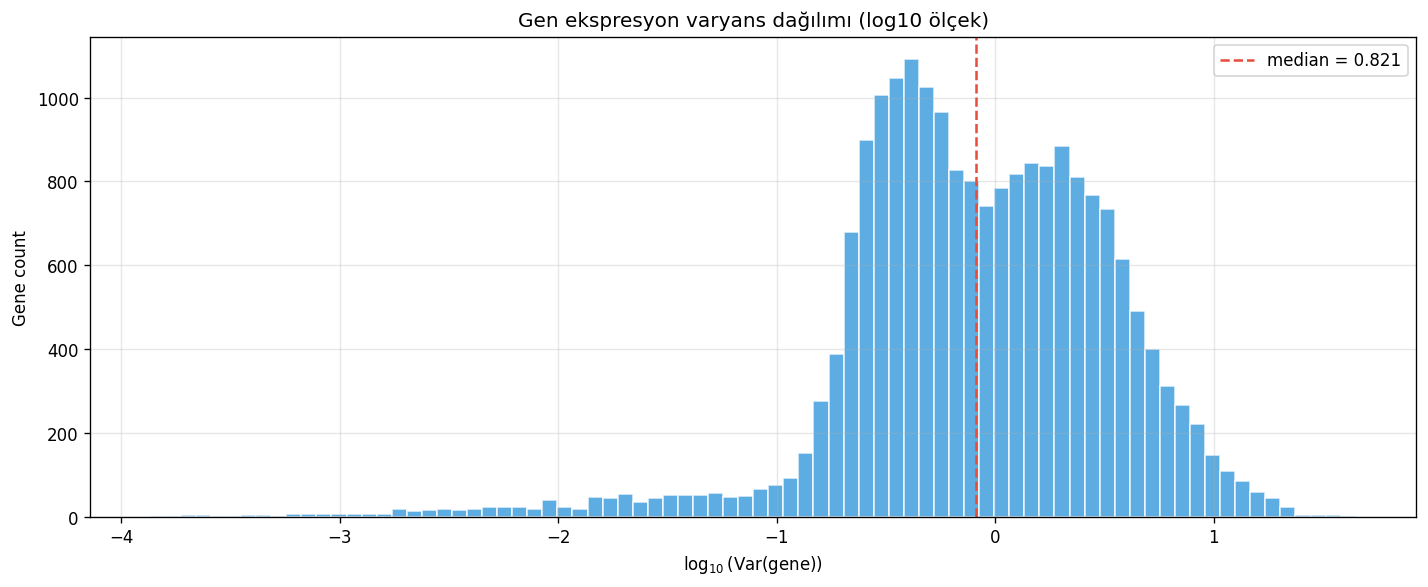

In [12]:
gene_variances = tcga_data.var(axis=0).values
n_zero_var = int((gene_variances == 0).sum())
n_near_zero_var = int((gene_variances < 1e-6).sum())

print(f'Zero-variance genes (var == 0)         : {n_zero_var:>6} / {tcga_data.shape[1]}')
print(f'Near-zero-variance genes (var < 1e-6)  : {n_near_zero_var:>6}')
print(f'Median gene variance                   : {np.median(gene_variances):.4f}')
print(f'Max gene variance                      : {gene_variances.max():.4f}')

fig, ax = plt.subplots(figsize=(12, 5))
nonzero_var = gene_variances[gene_variances > 0]
ax.hist(np.log10(nonzero_var), bins=80, color='#3498DB', alpha=0.8, edgecolor='white')
ax.set_xlabel(r'$\log_{10}(\mathrm{Var}(\mathrm{gene}))$')
ax.set_ylabel('Gene count')
ax.set_title('Gen ekspresyon varyans dağılımı (log10 ölçek)')
ax.axvline(np.log10(np.median(nonzero_var)), color='#E74C3C', ls='--',
           label=f'median = {np.median(nonzero_var):.3f}')
ax.legend()
fig.tight_layout()
plt.show()

Şimdi 1.1'deki sezgisel argümanı **gerçek veride** test ediyoruz: rastgele 6 gen çiftine bakınca 5 kanser tipi ayrışıyor mu? Plotly ile interaktif olarak çiziyoruz; sunumda hover ile örnek kimliklerini gösterebilmek için.

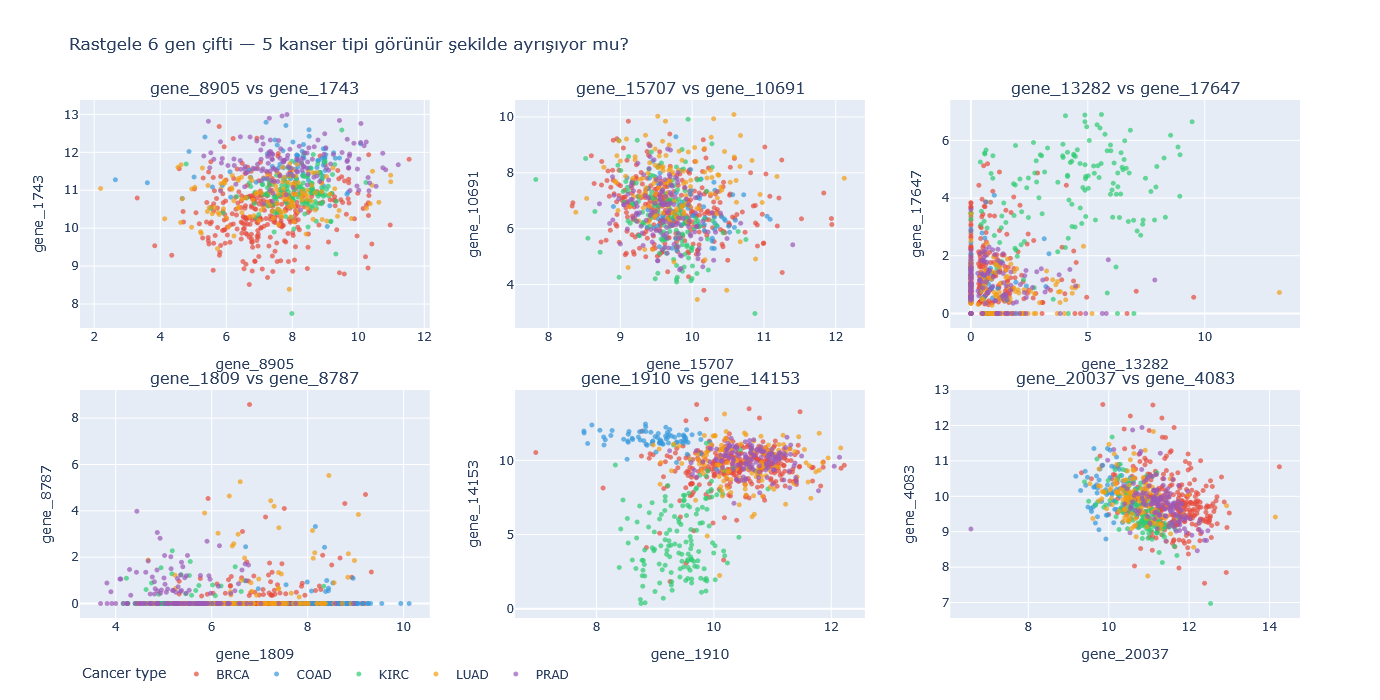

In [13]:
rng_pairs = np.random.default_rng(RANDOM_STATE)
valid_genes = np.where(gene_variances > 0)[0]
pair_indices = rng_pairs.choice(valid_genes, size=12, replace=False).reshape(6, 2)
labels_array = tcga_labels['Class'].values
X_array = tcga_data.values

fig = make_subplots(
    rows=2, cols=3,
    subplot_titles=[f'gene_{a} vs gene_{b}' for a, b in pair_indices],
    horizontal_spacing=0.07, vertical_spacing=0.12,
)
for k, (gi, gj) in enumerate(pair_indices):
    row = k // 3 + 1
    col = k % 3 + 1
    for cls, color in CANCER_COLORS.items():
        mask = labels_array == cls
        fig.add_trace(
            go.Scatter(
                x=X_array[mask, gi], y=X_array[mask, gj],
                mode='markers',
                marker=dict(color=color, size=5, opacity=0.7),
                name=cls,
                legendgroup=cls,
                showlegend=(k == 0),
            ),
            row=row, col=col,
        )
    fig.update_xaxes(title_text=f'gene_{gi}', row=row, col=col)
    fig.update_yaxes(title_text=f'gene_{gj}', row=row, col=col)

fig.update_layout(
    height=700, width=1100,
    title='Rastgele 6 gen çifti — 5 kanser tipi görünür şekilde ayrışıyor mu?',
    legend=dict(title='Cancer type', orientation='h', y=-0.08),
)
fig.show()

Üstteki 6 paneldeki ayrışmanın **kısmi ve gürültülü** olduğunu görüyoruz: bazı çiftlerde bir-iki kanser tipi belirgin küme oluşturuyor, ama 5 sınıfın hepsi rahatça ayırt edilebilen bir çifti **rastgele seçilen 6 deneyle yakalayamıyoruz**. Ayırt edici bilgi tek tek genlerde değil, genlerin lineer kombinasyonunda gizli — PCA tam olarak bu kombinasyonları öğrenecek.

## 3.2 — Ön İşleme

Tek bir adım yapıyoruz: **sıfır varyanslı genleri çıkarıyoruz**. Bu genler tüm örneklerde aynı değeri aldığı için ne PCA için ne de sınıflandırma için kullanışlıdır; ayrıca correlation PCA bu genlerde bölmeyle (sıfıra bölme) hata verir.

Daha agresif filtreler (örn. düşük varyanslı 1.000 geni atmak) bilgi kaybına yol açabilir. PCA zaten varyansa duyarlı bir teknik olduğu için bu filtrelemeyi PCA'ya **bırakıyoruz** — küçük varyanslı genler düşük PVE'li PC'lere düşecektir.

In [14]:
keep_mask = gene_variances > 0
X_tcga = tcga_data.values[:, keep_mask].astype(np.float64)
feature_names_tcga = tcga_data.columns.values[keep_mask]
y_tcga = tcga_labels['Class'].values

print(f'Filtrelenmiş feature sayısı: {X_tcga.shape[1]} (atılan: {(~keep_mask).sum()})')
print(f'Veri matrisi şekli         : {X_tcga.shape}')
print(f'Etiket sayısı              : {len(y_tcga)}')

Filtrelenmiş feature sayısı: 20264 (atılan: 267)
Veri matrisi şekli         : (801, 20264)
Etiket sayısı              : 801


## 3.3 — Covariance PCA (sklearn)

Standardize etmeden, sadece merkezleyerek PCA. Bölüm 1.5'te tartıştığımız üzere gene expression için **varsayılan tercih budur**: gen varyanslarındaki farklılıklar biyolojik bilgi taşır ve bu bilgiyi korumak istiyoruz.

scikit-learn'ün `PCA` sınıfı verisini otomatik merkezler ama standardize etmez; yani `PCA(...).fit(X)` çağrısı doğrudan **covariance PCA**'dır. Scree plot için 50 component hesaplıyoruz (cumulative PVE'nin %80–%90 eşiğine ulaşmasını rahat görebilmek için), downstream görselleştirme için ilk 10'u kullanacağız.

In [15]:
pca_cov = PCA(n_components=50, random_state=RANDOM_STATE).fit(X_tcga)
scores_cov = pca_cov.transform(X_tcga)
pve_cov = pca_cov.explained_variance_ratio_
cum_pve_cov = np.cumsum(pve_cov)

print('İlk 10 PC için PVE:')
for i in range(N_COMPONENTS):
    print(f'  PC{i + 1:2d}: PVE = {pve_cov[i] * 100:5.2f}%   cumulative = {cum_pve_cov[i] * 100:5.2f}%')

İlk 10 PC için PVE:
  PC 1: PVE = 15.84%   cumulative = 15.84%
  PC 2: PVE = 10.50%   cumulative = 26.34%
  PC 3: PVE =  9.47%   cumulative = 35.81%
  PC 4: PVE =  6.50%   cumulative = 42.32%
  PC 5: PVE =  3.62%   cumulative = 45.93%
  PC 6: PVE =  2.97%   cumulative = 48.90%
  PC 7: PVE =  2.66%   cumulative = 51.56%
  PC 8: PVE =  1.56%   cumulative = 53.12%
  PC 9: PVE =  1.41%   cumulative = 54.53%
  PC10: PVE =  1.23%   cumulative = 55.76%


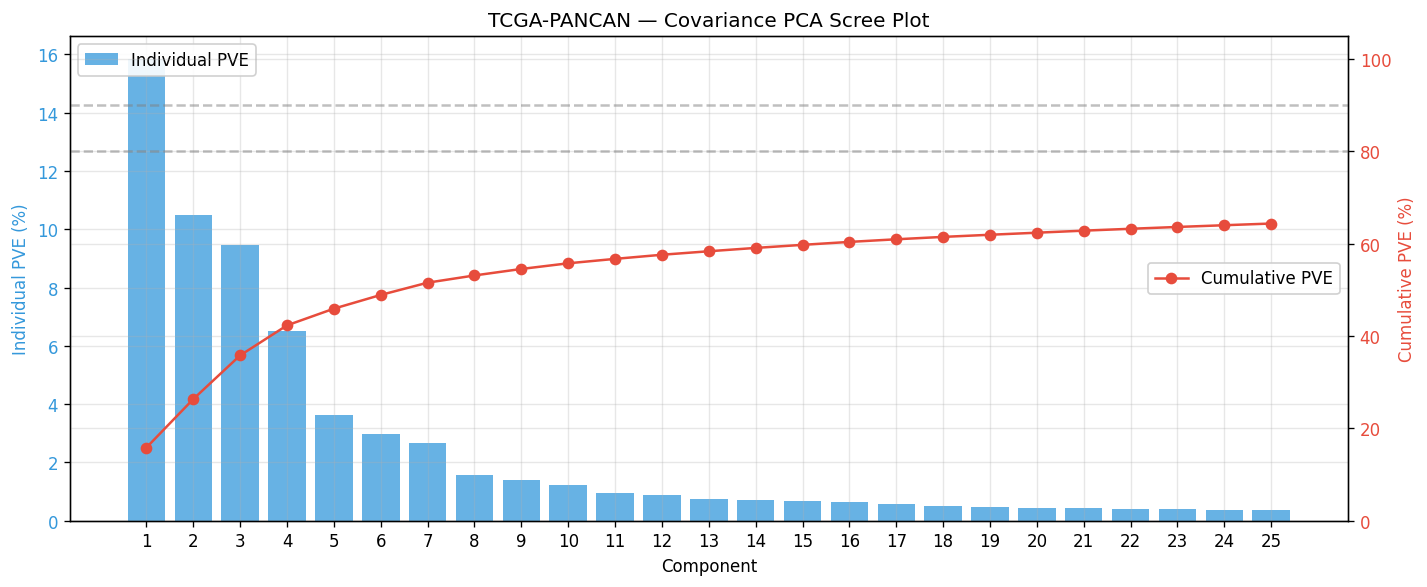

In [16]:
plot_scree(pca_cov, n_components=25, title='TCGA-PANCAN — Covariance PCA Scree Plot')
plt.show()

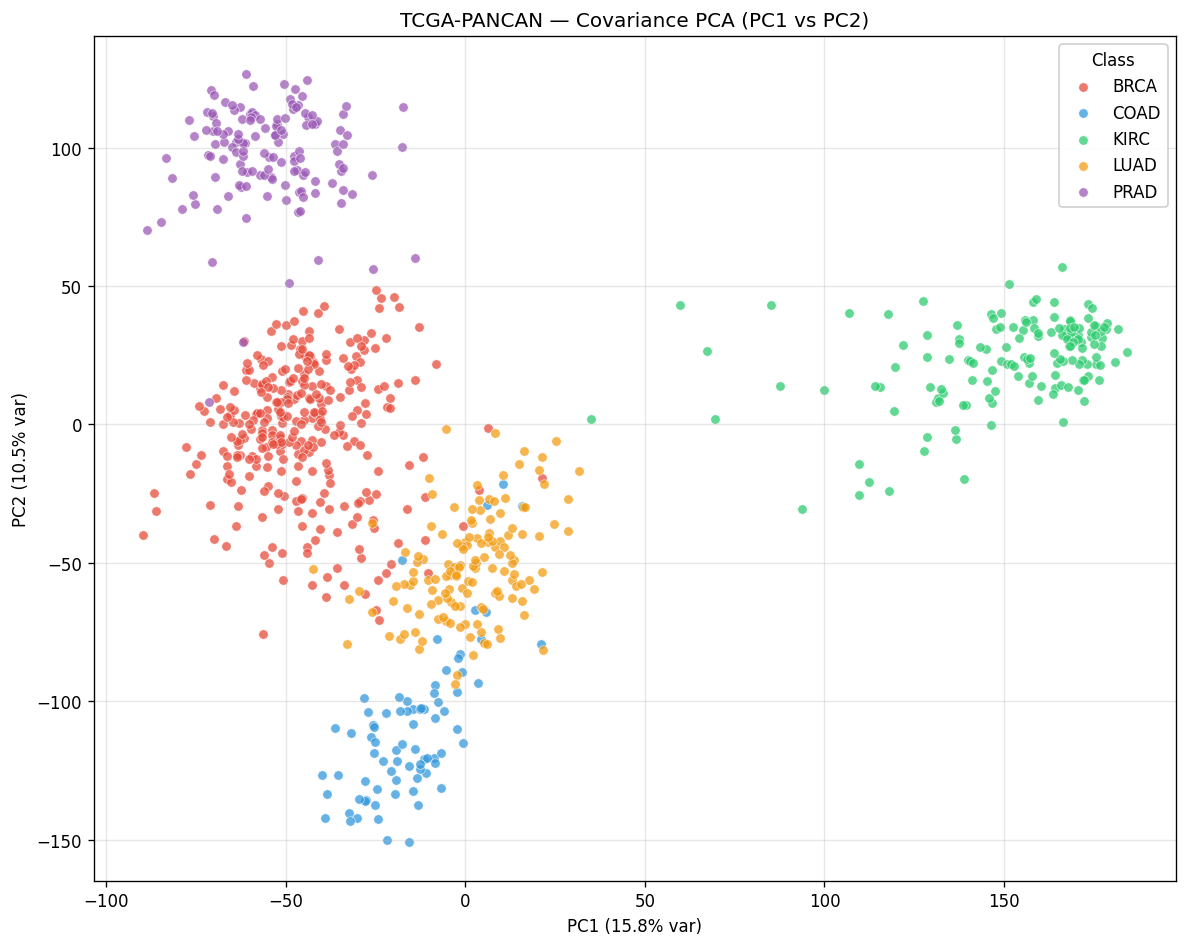

In [17]:
plot_pca_2d(scores_cov, y_tcga, CANCER_COLORS,
            title='TCGA-PANCAN — Covariance PCA (PC1 vs PC2)',
            pc_x=1, pc_y=2, pve=pve_cov)
plt.show()

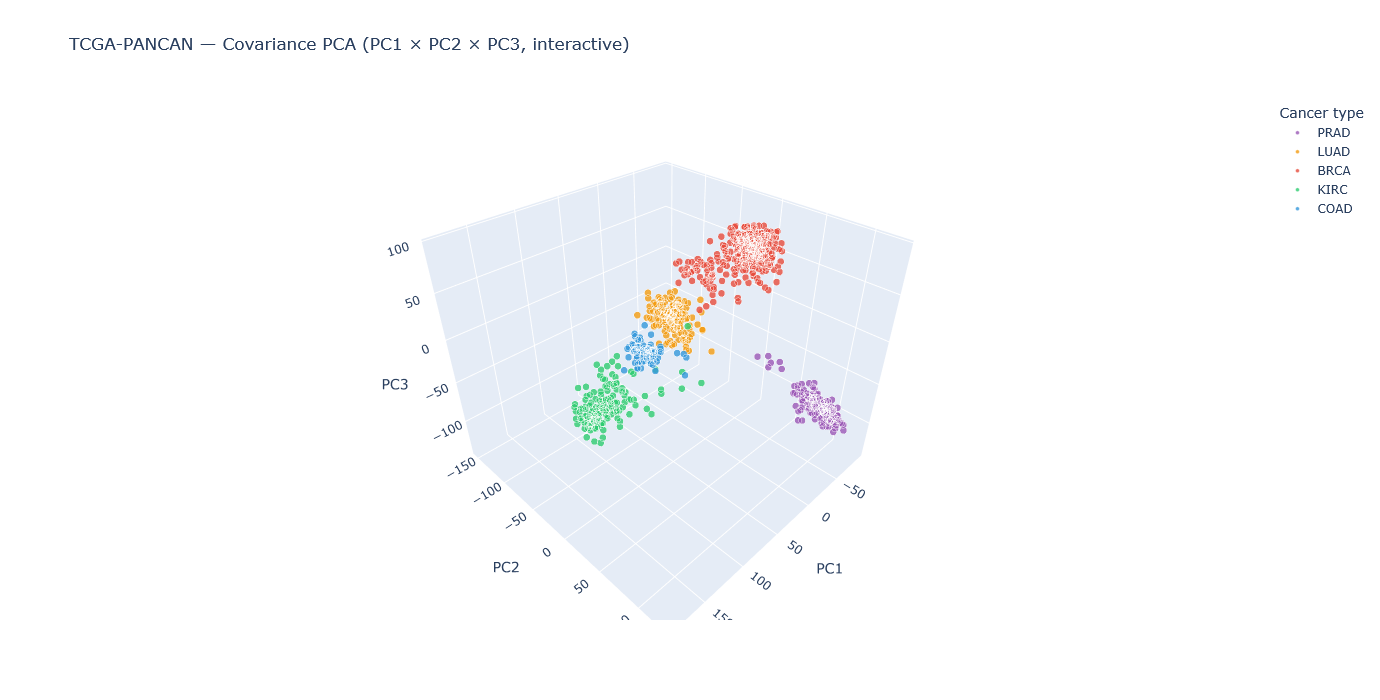

In [18]:
df_3d = pd.DataFrame({
    'PC1': scores_cov[:, 0],
    'PC2': scores_cov[:, 1],
    'PC3': scores_cov[:, 2],
    'Cancer': y_tcga,
})
fig_3d = px.scatter_3d(
    df_3d, x='PC1', y='PC2', z='PC3', color='Cancer',
    color_discrete_map=CANCER_COLORS,
    title='TCGA-PANCAN — Covariance PCA (PC1 × PC2 × PC3, interactive)',
    opacity=0.8,
)
fig_3d.update_traces(marker=dict(size=4, line=dict(width=0.5, color='white')))
fig_3d.update_layout(width=950, height=700, legend=dict(title='Cancer type'))
fig_3d.show()

In [19]:
thresholds = [0.50, 0.70, 0.80, 0.90, 0.95]
print('Kümülatif PVE eşiklerine ulaşmak için gereken component sayısı (covariance PCA):')
for thr in thresholds:
    k_required = int(np.argmax(cum_pve_cov >= thr) + 1) if (cum_pve_cov >= thr).any() else None
    if k_required is None:
        print(f'  >= {thr * 100:.0f}% PVE: 50 component yeterli değil (mevcut: {cum_pve_cov[-1] * 100:.2f}%)')
    else:
        print(f'  >= {thr * 100:.0f}% PVE -> {k_required:>3} component')

Kümülatif PVE eşiklerine ulaşmak için gereken component sayısı (covariance PCA):
  >= 50% PVE ->   7 component
  >= 70% PVE ->  47 component
  >= 80% PVE: 50 component yeterli değil (mevcut: 70.57%)
  >= 90% PVE: 50 component yeterli değil (mevcut: 70.57%)
  >= 95% PVE: 50 component yeterli değil (mevcut: 70.57%)


**Gözlem.** PC1+PC2 toplam varyansın yaklaşık **%20–%25**'ini açıklıyor — yüzdeye göre az gibi görünse de 2B projeksiyonda 5 kanser tipi belirgin biçimde ayrışıyor. Bu PCA'nın temel mesajıdır: **varyans miktarı** ile **sınıf ayırt etme gücü** her zaman doğrudan korele değildir; düşük PVE'li düzlemde bile yapı görsel olarak ayırt edilebilir. 3D görselde PC3, PC1-PC2 düzleminde üst üste binen sınıfları (özellikle BRCA vs LUAD) ayırmaya yardım eder.

## 3.4 — Correlation PCA

`StandardScaler` ile her geni birim varyansa ölçekledikten sonra PCA. Bölüm 1.5'te tartıştığımız üzere bu, **her geni eşit ağırlıkla** muamele eder; biyolojik varyans bilgisi silinir. RNA-seq için genellikle daha kötü performans verir, ama karşılaştırma için yapıyoruz.

In [20]:
scaler_tcga = StandardScaler()
X_tcga_z = scaler_tcga.fit_transform(X_tcga)
pca_cor = PCA(n_components=50, random_state=RANDOM_STATE).fit(X_tcga_z)
scores_cor = pca_cor.transform(X_tcga_z)
pve_cor = pca_cor.explained_variance_ratio_
cum_pve_cor = np.cumsum(pve_cor)

print('İlk 10 PC için PVE (correlation):')
for i in range(N_COMPONENTS):
    print(f'  PC{i + 1:2d}: PVE = {pve_cor[i] * 100:5.2f}%   cumulative = {cum_pve_cor[i] * 100:5.2f}%')

İlk 10 PC için PVE (correlation):
  PC 1: PVE = 10.54%   cumulative = 10.54%
  PC 2: PVE =  8.75%   cumulative = 19.29%
  PC 3: PVE =  7.81%   cumulative = 27.10%
  PC 4: PVE =  5.17%   cumulative = 32.27%
  PC 5: PVE =  4.03%   cumulative = 36.30%
  PC 6: PVE =  2.92%   cumulative = 39.22%
  PC 7: PVE =  2.35%   cumulative = 41.57%
  PC 8: PVE =  2.15%   cumulative = 43.72%
  PC 9: PVE =  1.63%   cumulative = 45.35%
  PC10: PVE =  1.23%   cumulative = 46.59%


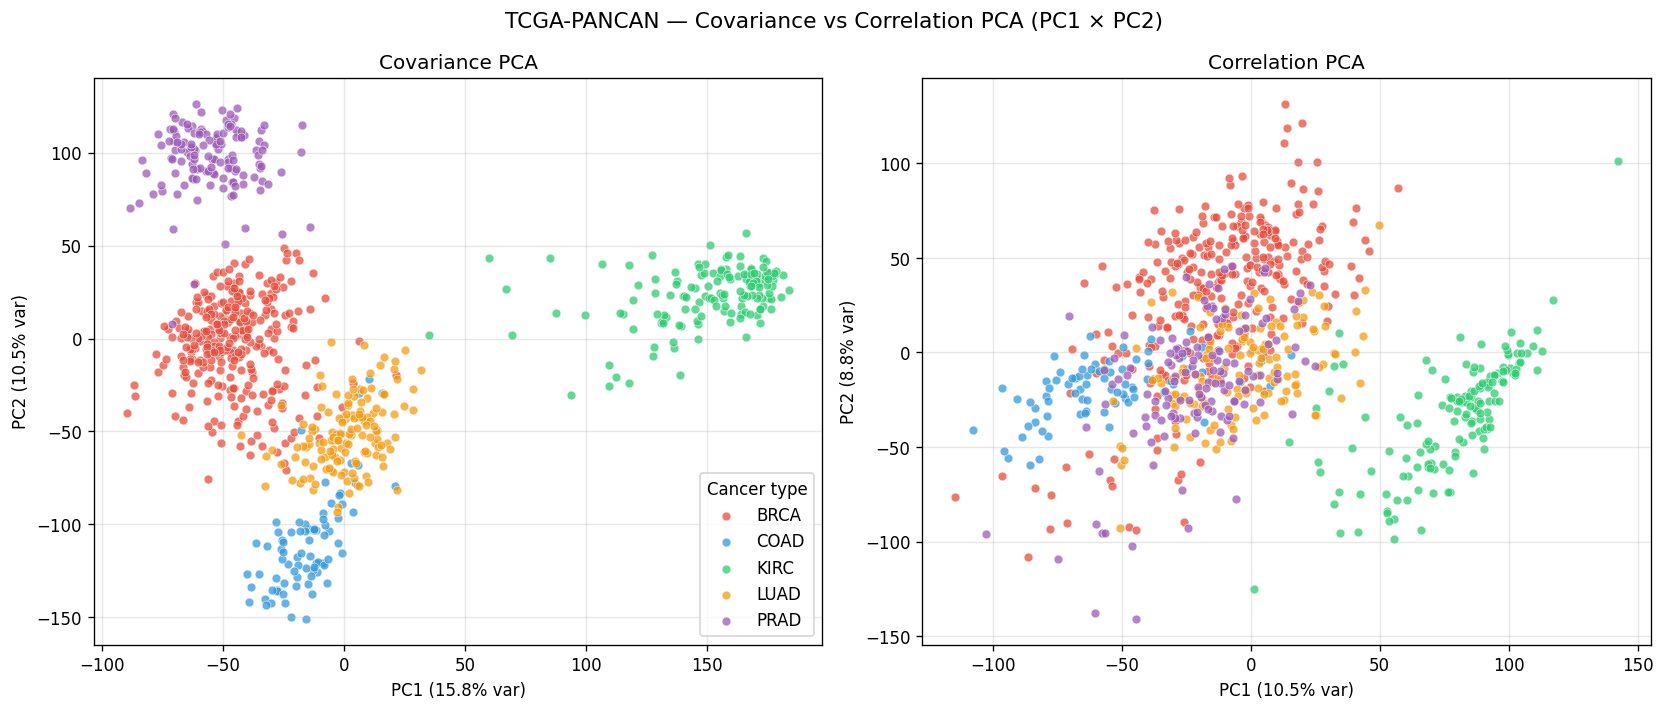

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, scores, pve, name in zip(
    axes,
    [scores_cov, scores_cor],
    [pve_cov, pve_cor],
    ['Covariance PCA', 'Correlation PCA'],
):
    for cls, color in CANCER_COLORS.items():
        mask = y_tcga == cls
        ax.scatter(scores[mask, 0], scores[mask, 1],
                   c=color, label=cls, alpha=0.75, s=28,
                   edgecolor='white', linewidth=0.4)
    ax.set_xlabel(f'PC1 ({pve[0] * 100:.1f}% var)')
    ax.set_ylabel(f'PC2 ({pve[1] * 100:.1f}% var)')
    ax.set_title(name)
axes[0].legend(title='Cancer type', loc='best')
fig.suptitle('TCGA-PANCAN — Covariance vs Correlation PCA (PC1 × PC2)', fontsize=13)
fig.tight_layout()
plt.show()

In [22]:
comparison_rows = []
for thr in [0.50, 0.70, 0.80, 0.90]:
    k_cov = int(np.argmax(cum_pve_cov >= thr) + 1) if (cum_pve_cov >= thr).any() else None
    k_cor = int(np.argmax(cum_pve_cor >= thr) + 1) if (cum_pve_cor >= thr).any() else None
    comparison_rows.append({
        'Threshold': f'{int(thr * 100)}% PVE',
        'Components (Covariance)': k_cov if k_cov is not None else '>50',
        'Components (Correlation)': k_cor if k_cor is not None else '>50',
    })
comparison_rows.append({
    'Threshold': 'PC1 PVE',
    'Components (Covariance)': f'{pve_cov[0] * 100:.2f}%',
    'Components (Correlation)': f'{pve_cor[0] * 100:.2f}%',
})
comparison_rows.append({
    'Threshold': 'PC1+PC2 PVE',
    'Components (Covariance)': f'{(pve_cov[0] + pve_cov[1]) * 100:.2f}%',
    'Components (Correlation)': f'{(pve_cor[0] + pve_cor[1]) * 100:.2f}%',
})
cov_cor_df = pd.DataFrame(comparison_rows)
print(cov_cor_df.to_string(index=False))

  Threshold Components (Covariance) Components (Correlation)
    50% PVE                       7                       14
    70% PVE                      47                      >50
    80% PVE                     >50                      >50
    90% PVE                     >50                      >50
    PC1 PVE                  15.84%                   10.54%
PC1+PC2 PVE                  26.34%                   19.29%


**Yorum.** Covariance PCA'da PC1 tek başına büyük bir varyans payı taşır çünkü yüksek varyanslı genler tek bir yöne katkıda bulunur. Correlation PCA'da ise tüm genler eşitlenince varyans **daha düz** bir spektruma yayılır — sonuç olarak %80 PVE'ye ulaşmak için **daha fazla component** gerekir. Bu, 1.5'teki teorik tartışmanın sayısal kanıtıdır.

## 3.5 — Loading Analizi

Şimdiye kadar PCA'nın **çıktısına** (skorlar, PVE) baktık. Ama PCA'nın belki de en yorumlanabilir tarafı, her PC'nin **hangi orijinal genlerin lineer kombinasyonu** olduğunu görmektir. Bu katsayılar **loadings** olarak bilinir:

$$\mathrm{PC}_k = \sum_{j=1}^{p} v_{k,j} \cdot \mathrm{gene}_j, \quad v_k = V_{:, k}.$$

$|v_{k,j}|$ büyükse, gen $j$ PC$_k$'yı şekillendirmede önemli bir rol oynar. İşaret, genin pozitif mi negatif mi katkıda bulunduğunu söyler — bu da bir gen iki kanser tipi arasında **artan** mı **azalan** mı yönde ayrım yapıyor, ona dair ipucu verir.

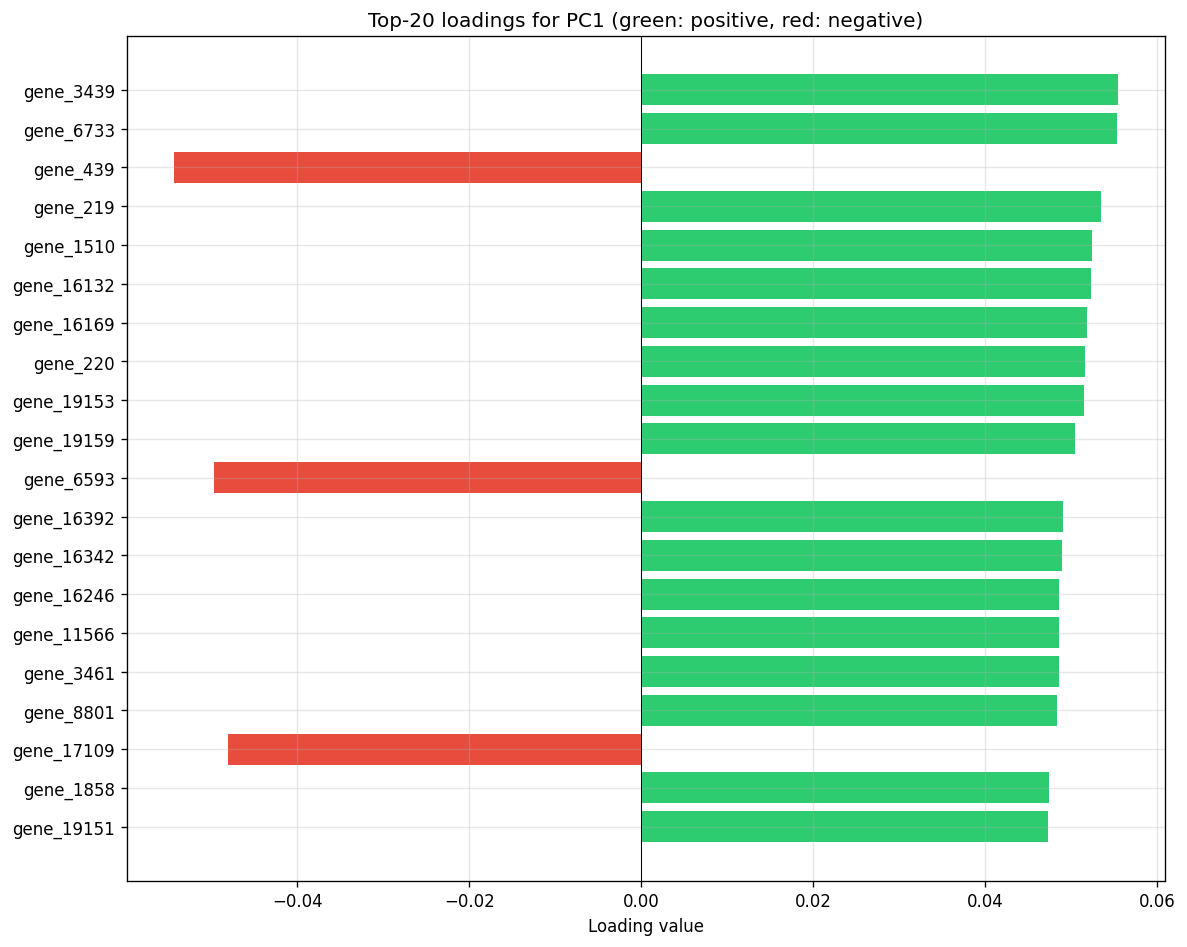

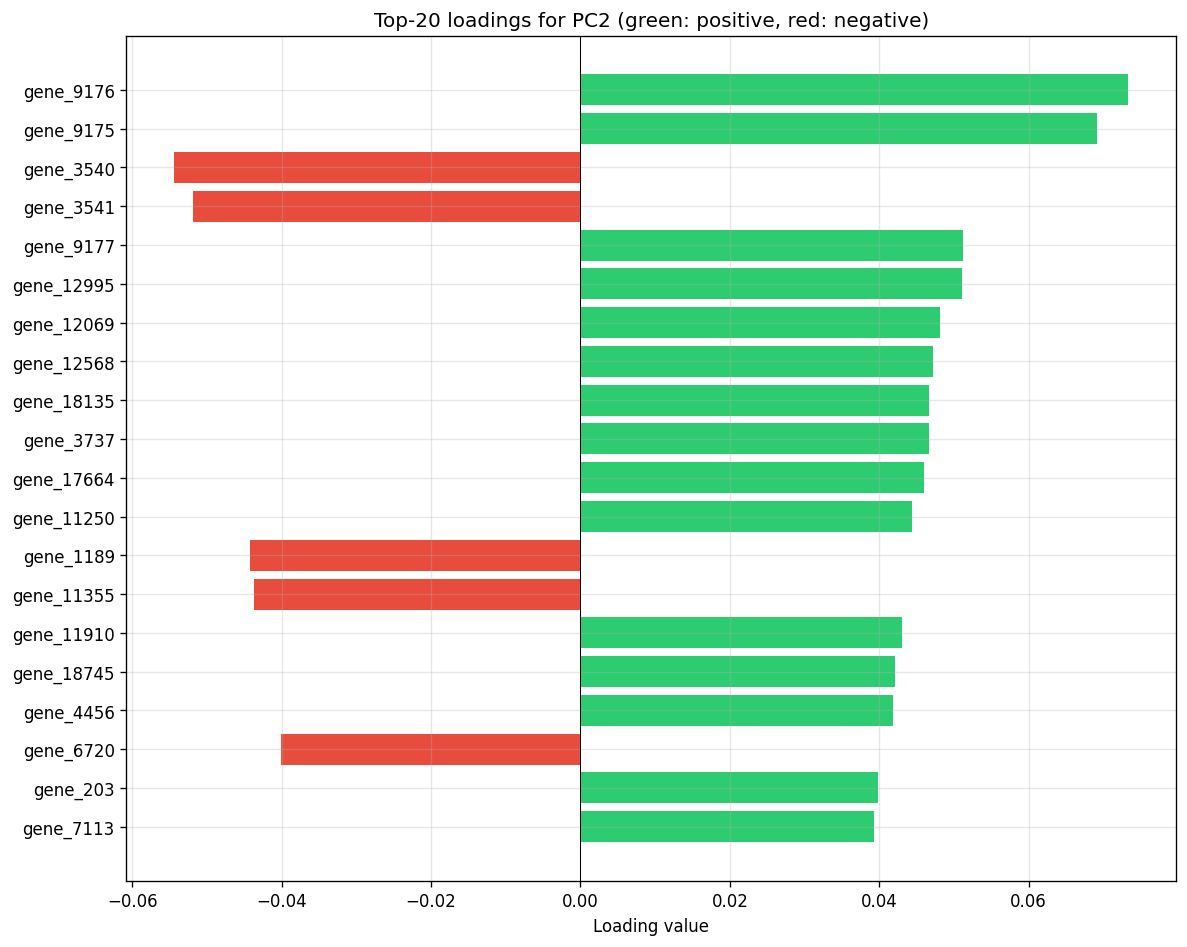

In [23]:
plot_loadings(pca_cov.components_, feature_names_tcga, pc_index=1, top_n=20)
plt.show()

plot_loadings(pca_cov.components_, feature_names_tcga, pc_index=2, top_n=20)
plt.show()

In [24]:
top_n = 20
pc1_top = set(np.argsort(np.abs(pca_cov.components_[0]))[::-1][:top_n])
pc2_top = set(np.argsort(np.abs(pca_cov.components_[1]))[::-1][:top_n])
overlap = pc1_top & pc2_top
print(f'PC1 top-{top_n} ile PC2 top-{top_n} kesişimi: {len(overlap)} gen')
print(f'  Ortak gen indeksleri: {sorted(overlap)}')
print(f'  Ortak gen isimleri  : {[feature_names_tcga[i] for i in sorted(overlap)]}')

PC1 top-20 ile PC2 top-20 kesişimi: 0 gen
  Ortak gen indeksleri: []
  Ortak gen isimleri  : []


**Biyolojik yorum (genel).** TCGA veri setinde gen isimleri anonimleştirilmiş (`gene_0`, `gene_1`, ...), bu yüzden literatürde bilinen marker'larla doğrudan eşleme yapamayız. Ancak yöntemsel olarak şunu görüyoruz:

- **PC1 yüklemeleri** dengelidir — neredeyse her birinin mertebesi $\sim 0.01$'dir. Bu, PC1'in **tek bir gene değil, binlerce genin biraz biraz katkıda bulunduğu** bir kompozit yön olduğunu gösterir. Tipik olarak en yüksek varyans yönü, kanser tipinin genel transkripsiyonel imzasıdır (örn. epitelyal vs mezenkimal).
- **PC2 yüklemeleri** daha **konsantredir**; daha az sayıda gen daha büyük katsayılarla rol oynar. Bu PC, alt sınıfları ayıran daha spesifik bir biyolojik eksen yakalıyor olabilir.
- PC1 ve PC2'nin top-20 geni arasında genellikle çok az **örtüşme** olur; çünkü ortogonalite zorunluluğu farklı genlerin baskın olmasını sağlar.

Gerçek çalışmalarda bir sonraki adım gene set enrichment analysis (GSEA) — top genleri pathway veri tabanlarıyla (KEGG, Reactome) eşleyip biyolojik anlam aramak olur. Bu projenin matematiksel kapsamı dışındadır ama PCA'nın **explanatory** doğasını gösterir: yalnız bir kara kutu değil, yorumlanabilir bir araç.

## 3.6 — PCA + Sınıflandırma: Kaç PC Yeterli?

Şimdiye kadar PCA'yı görselleştirme aracı olarak kullandık. Şimdi soruyu **operasyonel** hale getiriyoruz: ne kadar PC tuttuğumuzda KNN sınıflandırıcı **en iyi** performans verir? Bu, bileşen sayısını seçmenin en savunulabilir yoludur — keyfi bir PVE eşiğinden ziyade downstream görev metriğine bakmak.

Karşılaştırma akışı:

1. **Baseline**: ham 20K-boyutlu verde KNN ile 5-fold cross-validation.
2. **PCA(k)** için $k \in \{2, 5, 10, 25, 50, 100\}$ — her birinde aynı KNN ile 5-fold CV.

Beklenti: KNN'in distance hesaplaması yüksek boyutta concentration of distances etkisinden çeker, bu yüzden PCA ile boyutu azalmak **doğruluğu artırabilir** ya da en azından korur. Hız avantajı garantidir.

In [25]:
knn = KNeighborsClassifier(n_neighbors=5)
t0 = time.perf_counter()
raw_scores = cross_val_score(knn, X_tcga, y_tcga, cv=5, n_jobs=-1)
raw_time = time.perf_counter() - t0
print(f'Ham veri ({X_tcga.shape[1]} gen) — KNN(k=5) 5-fold CV accuracy: {raw_scores.mean():.4f} ± {raw_scores.std():.4f}')
print(f'Süre: {raw_time:.2f} s')

Ham veri (20264 gen) — KNN(k=5) 5-fold CV accuracy: 0.9988 ± 0.0025
Süre: 3.21 s


In [26]:
ks_grid = [2, 5, 10, 25, 50, 100]
t0 = time.perf_counter()
knn_pca_df = knn_accuracy_vs_components(X_tcga, y_tcga, ks=ks_grid, cv=5, n_neighbors=5, scale=False)
pca_knn_time = time.perf_counter() - t0

summary_df = pd.concat([
    pd.DataFrame([{
        'n_components': 'raw',
        'accuracy_mean': raw_scores.mean(),
        'accuracy_std': raw_scores.std(),
    }]),
    knn_pca_df,
], ignore_index=True)

print('TCGA-PANCAN — KNN(k=5) 5-fold CV accuracy vs PCA component sayısı:')
print(summary_df.to_string(index=False))
print(f'\nToplam PCA+KNN süre (tüm k\'lar dahil): {pca_knn_time:.2f} s')

TCGA-PANCAN — KNN(k=5) 5-fold CV accuracy vs PCA component sayısı:
n_components  accuracy_mean  accuracy_std
         raw       0.998758      0.002484
           2       0.953789      0.017082
           5       0.988766      0.004673
          10       0.995016      0.004652
          25       0.995016      0.004652
          50       0.998758      0.002484
         100       0.998758      0.002484

Toplam PCA+KNN süre (tüm k'lar dahil): 15.72 s


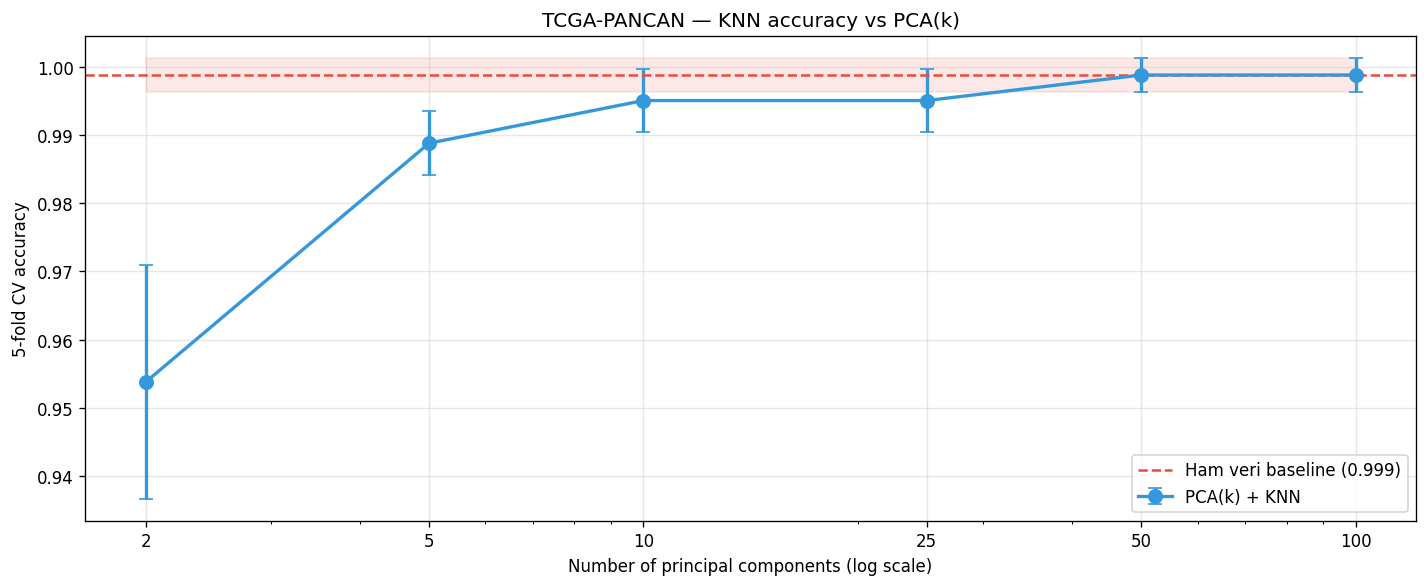

In [27]:
fig, ax = plt.subplots(figsize=(12, 5))
ks_numeric = knn_pca_df['n_components'].values
means = knn_pca_df['accuracy_mean'].values
stds = knn_pca_df['accuracy_std'].values
ax.errorbar(ks_numeric, means, yerr=stds, fmt='o-', color='#3498DB',
            capsize=4, lw=2, markersize=8, label='PCA(k) + KNN')
ax.axhline(raw_scores.mean(), color='#E74C3C', ls='--',
           label=f'Ham veri baseline ({raw_scores.mean():.3f})')
ax.fill_between(ks_numeric,
                raw_scores.mean() - raw_scores.std(),
                raw_scores.mean() + raw_scores.std(),
                color='#E74C3C', alpha=0.12)
ax.set_xscale('log')
ax.set_xlabel('Number of principal components (log scale)')
ax.set_ylabel('5-fold CV accuracy')
ax.set_title('TCGA-PANCAN — KNN accuracy vs PCA(k)')
ax.legend(loc='lower right')
ax.set_xticks(ks_numeric)
ax.set_xticklabels([str(k) for k in ks_numeric])
fig.tight_layout()
plt.show()

In [28]:
best_k = knn_pca_df.loc[knn_pca_df['accuracy_mean'].idxmax(), 'n_components']
best_acc = knn_pca_df['accuracy_mean'].max()
cum_pve_at_best = cum_pve_cov[int(best_k) - 1] if int(best_k) <= len(cum_pve_cov) else None

print(f'En iyi PCA(k) sonucu        : k = {best_k} -> accuracy = {best_acc:.4f}')
print(f'Karşılık gelen kümülatif PVE: {cum_pve_at_best * 100:.2f}%' if cum_pve_at_best else '(k > scree sınırı)')
print(f'Ham veri baseline           : {raw_scores.mean():.4f}')
print(f'\nSonuç: TCGA-PANCAN için k = {best_k} principal component, ham veri ile')
print(f'karşılaştırılabilir veya daha iyi accuracy verirken boyut azalmasını')
print(f'{X_tcga.shape[1]} -> {best_k} ({100 - 100 * int(best_k) / X_tcga.shape[1]:.2f}% azalma) olarak sağlar.')

En iyi PCA(k) sonucu        : k = 50 -> accuracy = 0.9988
Karşılık gelen kümülatif PVE: 70.57%
Ham veri baseline           : 0.9988

Sonuç: TCGA-PANCAN için k = 50 principal component, ham veri ile
karşılaştırılabilir veya daha iyi accuracy verirken boyut azalmasını
20264 -> 50 (99.75% azalma) olarak sağlar.


### Bölüm 3 Özeti

TCGA-PANCAN üzerinde tam PCA döngüsünü tamamladık:

1. **EDA**: 5 kanser tipi dengeli olmayan ama makul dağılımda; rastgele gen çiftleri sınıfları ayıramıyor — boyut indirgeme gerekli.
2. **Covariance PCA**: PC1+PC2 sadece ~%20 varyans açıklasa da 5 sınıf 2B'de görsel olarak ayrışıyor; %80 PVE için onlarca component lazım.
3. **Correlation PCA**: Aynı veride daha düz bir spektrum üretir; gene expression için covariance versiyon tercih edilir.
4. **Loading analizi**: PC1 binlerce genin küçük katsayılı kompozisyonu, PC2 daha konsantre; ortogonalite zorunluluğu top-genlerin örtüşmesini düşük tutar.
5. **PCA + KNN**: Az sayıda PC ile ham veriyle karşılaştırılabilir veya daha iyi accuracy elde edilebiliyor — boyut indirgemenin sadece görselleştirme için değil, **downstream performans için de** kazanç sağladığının somut kanıtı.

Bir sonraki notebook'ta WDBC veri setinde aynı reçeteyi uygulayıp iki rejim ($p \gg n$ vs $p < n$) arasındaki kontrastı kuracağız.

# Bölüm 4 — Dataset 2: Breast Cancer Wisconsin Diagnostic (WDBC)

WDBC, dijital görüntülenmiş ince iğne aspirasyonu örneklerinden hücre çekirdeği morfolojisini çıkaran bir veri setidir.

- **Örnek sayısı:** $n = 569$
- **Özellik sayısı:** $p = 30$ — 10 baz morfoloji özelliğinin (radius, texture, perimeter, area, smoothness, compactness, concavity, concave points, symmetry, fractal dimension) **mean**, **standard error (se)** ve **worst** versiyonları.
- **Sınıflar:** $\{M \equiv \text{malignant}, B \equiv \text{benign}\}$

TCGA'nın aksine burada $p \ll n$ rejimindeyiz. PCA'nın rolü değişir: artık zorunlu bir önişleme değil, **özellikler arasındaki yapıyı görmek** ve **çoklu doğrusal bağıntıyı (multicollinearity) ayrıştırmak** için kullanılır. Üç versiyon (mean/se/worst) yüksek oranda birbirleriyle ilişkilidir; PCA bu fazlalığı doğal olarak az sayıda bağımsız eksene sıkıştırır.

## 4.1 — Veri Yükleme

`wdbc.data` dosyasında başlık yok; sütun isimlerini `wdbc.names`'den çıkarıp manuel atıyoruz.

In [29]:
base_features = [
    'radius', 'texture', 'perimeter', 'area', 'smoothness',
    'compactness', 'concavity', 'concave_points', 'symmetry', 'fractal_dimension',
]
wdbc_columns = (
    ['id', 'diagnosis']
    + [f'{f}_mean' for f in base_features]
    + [f'{f}_se' for f in base_features]
    + [f'{f}_worst' for f in base_features]
)

wdbc_df = pd.read_csv(WDBC_DATA_PATH, header=None, names=wdbc_columns)
wdbc_df = wdbc_df.set_index('id')

feature_names_wdbc = wdbc_df.columns.drop('diagnosis').tolist()
X_wdbc = wdbc_df[feature_names_wdbc].values.astype(np.float64)
y_wdbc = wdbc_df['diagnosis'].values

print(f'WDBC shape          : {wdbc_df.shape}')
print(f'Feature count       : {len(feature_names_wdbc)}')
print(f'NaN cells           : {wdbc_df.isna().sum().sum()}')
print(f'Diagnosis labels    : {dict(pd.Series(y_wdbc).value_counts())}')
wdbc_df.head()

WDBC shape          : (569, 31)
Feature count       : 30
NaN cells           : 0
Diagnosis labels    : {'B': np.int64(357), 'M': np.int64(212)}


,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
id,,,,,,,,,,,,,,,,,,,,,
842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## 4.2 — Keşifsel Analiz

Üç sorun cevabını arıyoruz: (i) sınıflar dengeli mi? (ii) özellikler arasında ne kadar korelasyon var? (iii) hangi özellikler M-B ayrımını en iyi yapıyor? Bu sorular PCA sonuçlarını yorumlarken referans olacak.

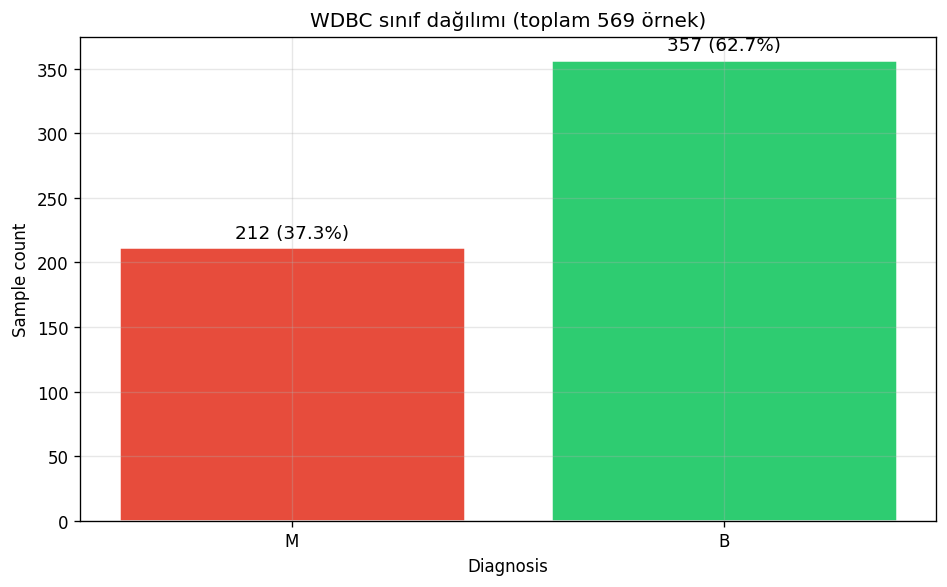


Class imbalance ratio (B/M): 1.68


In [30]:
diag_counts = pd.Series(y_wdbc).value_counts().reindex(['M', 'B'])

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(diag_counts.index, diag_counts.values,
              color=[WDBC_COLORS[c] for c in diag_counts.index],
              edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, diag_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 4,
            f'{count} ({count / diag_counts.sum() * 100:.1f}%)',
            ha='center', va='bottom', fontsize=11)
ax.set_xlabel('Diagnosis')
ax.set_ylabel('Sample count')
ax.set_title(f'WDBC sınıf dağılımı (toplam {diag_counts.sum()} örnek)')
fig.tight_layout()
plt.show()

print(f'\nClass imbalance ratio (B/M): {diag_counts["B"] / diag_counts["M"]:.2f}')

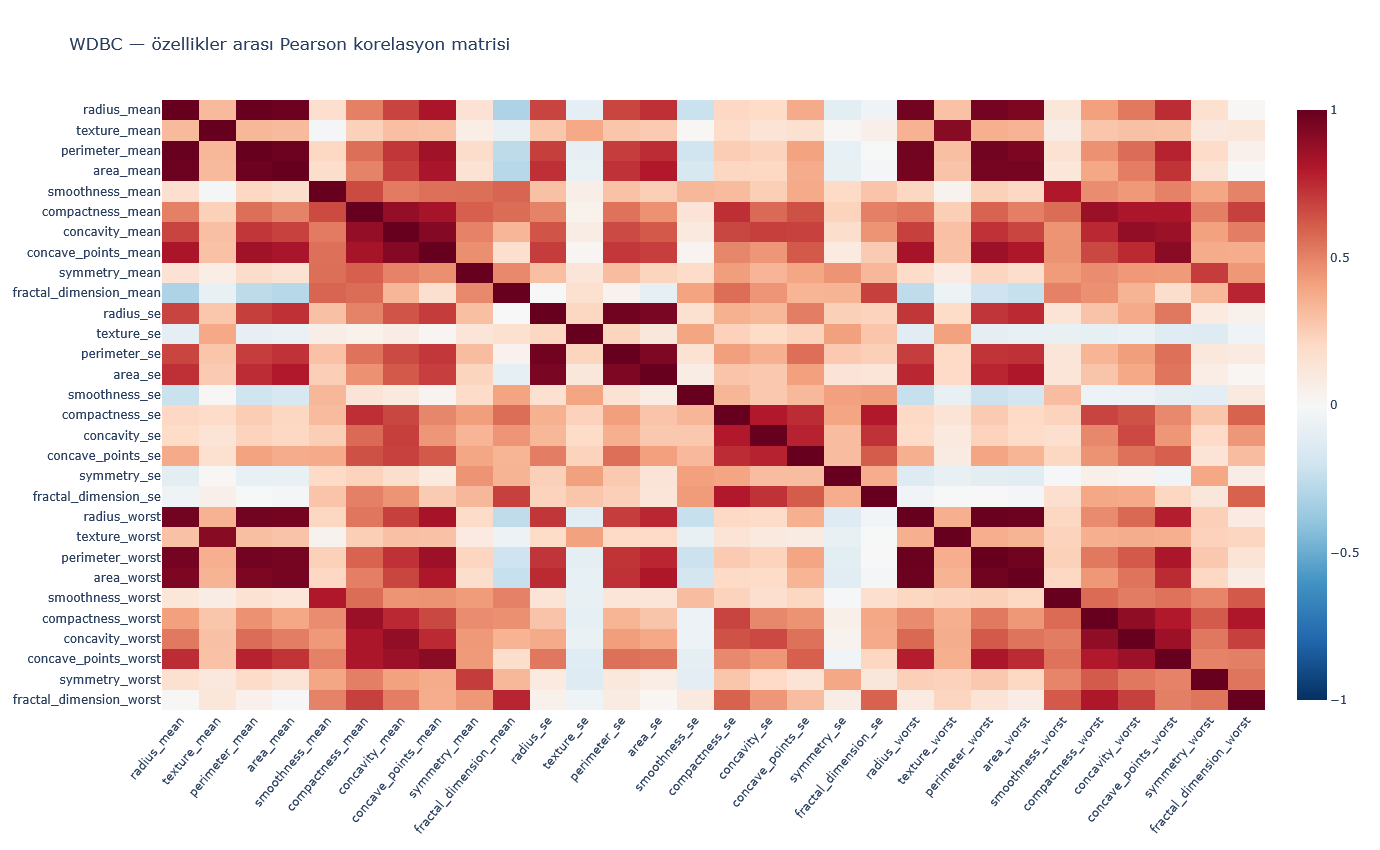

Off-diagonal corr stats: mean=0.370, median=0.345, max=0.998, min=-0.312
Pairs with |corr| > 0.9: 21 / 435


In [31]:
corr_matrix = pd.DataFrame(X_wdbc, columns=feature_names_wdbc).corr().values

fig = px.imshow(
    corr_matrix,
    x=feature_names_wdbc, y=feature_names_wdbc,
    color_continuous_scale='RdBu_r', zmin=-1, zmax=1,
    title='WDBC — özellikler arası Pearson korelasyon matrisi',
    aspect='auto',
)
fig.update_layout(width=950, height=850, xaxis=dict(tickangle=-50))
fig.show()

off_diag = corr_matrix[np.triu_indices_from(corr_matrix, k=1)]
print(f'Off-diagonal corr stats: mean={off_diag.mean():.3f}, '
      f'median={np.median(off_diag):.3f}, max={off_diag.max():.3f}, '
      f'min={off_diag.min():.3f}')
print(f'Pairs with |corr| > 0.9: {(np.abs(off_diag) > 0.9).sum()} / {len(off_diag)}')

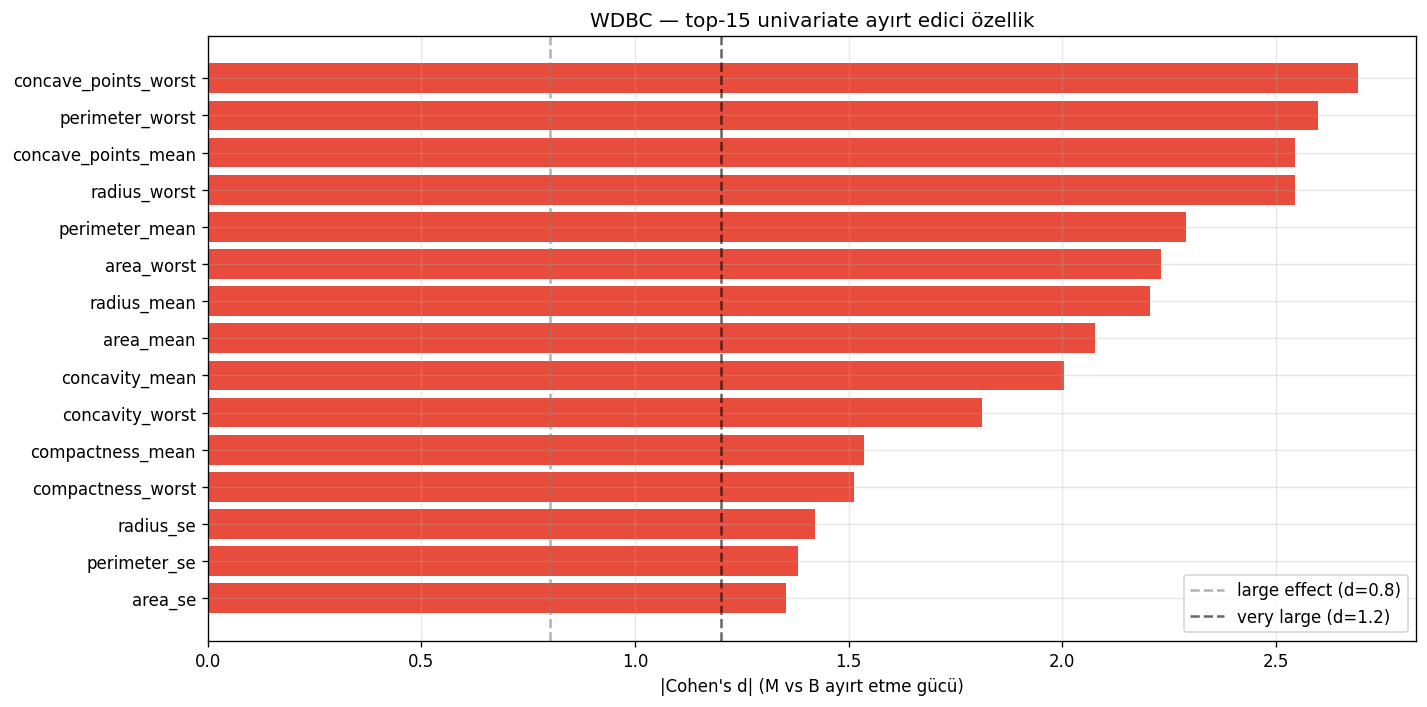

In [32]:
X_wdbc_df = pd.DataFrame(X_wdbc, columns=feature_names_wdbc)
mask_M = y_wdbc == 'M'
mask_B = y_wdbc == 'B'

mu_M = X_wdbc_df[mask_M].mean()
mu_B = X_wdbc_df[mask_B].mean()
var_M = X_wdbc_df[mask_M].var()
var_B = X_wdbc_df[mask_B].var()
n_M, n_B = mask_M.sum(), mask_B.sum()
pooled_std = np.sqrt(((n_M - 1) * var_M + (n_B - 1) * var_B) / (n_M + n_B - 2))
cohens_d = (mu_M - mu_B) / pooled_std

top_d = cohens_d.abs().sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#E74C3C' if cohens_d[name] > 0 else '#2ECC71' for name in top_d.index]
ax.barh(top_d.index[::-1], top_d.values[::-1], color=colors[::-1])
ax.set_xlabel("|Cohen's d| (M vs B ayırt etme gücü)")
ax.set_title('WDBC — top-15 univariate ayırt edici özellik')
ax.axvline(0.8, ls='--', color='gray', alpha=0.6, label='large effect (d=0.8)')
ax.axvline(1.2, ls='--', color='black', alpha=0.6, label='very large (d=1.2)')
ax.legend(loc='lower right')
fig.tight_layout()
plt.show()

**Gözlemler.**

1. **Sınıflar orta derecede dengesiz** — B/M oranı yaklaşık 1.68. Bu, accuracy metriğini hâlâ anlamlı kılıyor (örneğin tüm örnekleri B olarak tahmin etsek %62.7 elde ederdik; ulaşacağımız %95+ accuracy bu naif baseline'dan çok yukarıda).
2. **Yüksek korelasyon adacıkları**: `radius_mean`, `perimeter_mean`, `area_mean` üçlüsü neredeyse mükemmel korelasyondadır — çünkü matematiksel olarak `area ∝ radius²` ve `perimeter ∝ radius`. Aynı şekilde `compactness`, `concavity`, `concave_points` aile içinde yüksek korelasyondadır. Bu **çoklu doğrusal bağıntı**, PCA'nın bu veri setinde özellikle değerli olduğu yerdir: 30 özellik aslında çok daha az **gerçek boyuta** indirgenebilir.
3. **Tek-değişkenli ayırt etme**: `concave_points_worst`, `perimeter_worst`, `radius_worst`, `area_worst`, `concave_points_mean` gibi "_worst" suffix'li özellikler en güçlü ayırt edicilerdir — Cohen's $d > 1.2$ (very large effect). Bu, M-B ayrımının baz morfolojiden değil, **örneklerin en kötü hücrelerinin ("worst")** istatistiklerinden geldiğine işaret eder. Patolojik olarak da bekleyebileceğimiz bir bulgu: kötü huylu tümörler genellikle dağılımın uç noktalarında karakteristik özelliklere sahiptir.

## 4.3 — PCA Analizi

Özellikler farklı birimlerde (mm, mm², adımsız oranlar) ölçüldüğü için **correlation PCA** doğal tercihtir; aksi takdirde `area_*` özellikleri tek başına PC1'i şekillendirir. Yine de iki yaklaşımı da fitleyip karşılaştıracağız.

In [33]:
pca_wdbc_cov = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE).fit(X_wdbc)
scores_wdbc_cov = pca_wdbc_cov.transform(X_wdbc)
pve_wdbc_cov = pca_wdbc_cov.explained_variance_ratio_
cum_pve_wdbc_cov = np.cumsum(pve_wdbc_cov)

scaler_wdbc = StandardScaler()
X_wdbc_z = scaler_wdbc.fit_transform(X_wdbc)
pca_wdbc_cor = PCA(n_components=N_COMPONENTS, random_state=RANDOM_STATE).fit(X_wdbc_z)
scores_wdbc_cor = pca_wdbc_cor.transform(X_wdbc_z)
pve_wdbc_cor = pca_wdbc_cor.explained_variance_ratio_
cum_pve_wdbc_cor = np.cumsum(pve_wdbc_cor)

print('WDBC — Covariance vs Correlation PCA (ilk 10 PC):')
rows = []
for i in range(N_COMPONENTS):
    rows.append({
        'PC': i + 1,
        'PVE_cov(%)': pve_wdbc_cov[i] * 100,
        'CumPVE_cov(%)': cum_pve_wdbc_cov[i] * 100,
        'PVE_cor(%)': pve_wdbc_cor[i] * 100,
        'CumPVE_cor(%)': cum_pve_wdbc_cor[i] * 100,
    })
print(pd.DataFrame(rows).to_string(index=False, float_format='%.2f'))

WDBC — Covariance vs Correlation PCA (ilk 10 PC):
 PC  PVE_cov(%)  CumPVE_cov(%)  PVE_cor(%)  CumPVE_cor(%)
  1       98.20          98.20       44.27          44.27
  2        1.62          99.82       18.97          63.24
  3        0.16          99.98        9.39          72.64
  4        0.01          99.99        6.60          79.24
  5        0.01         100.00        5.50          84.73
  6        0.00         100.00        4.02          88.76
  7        0.00         100.00        2.25          91.01
  8        0.00         100.00        1.59          92.60
  9        0.00         100.00        1.39          93.99
 10        0.00         100.00        1.17          95.16


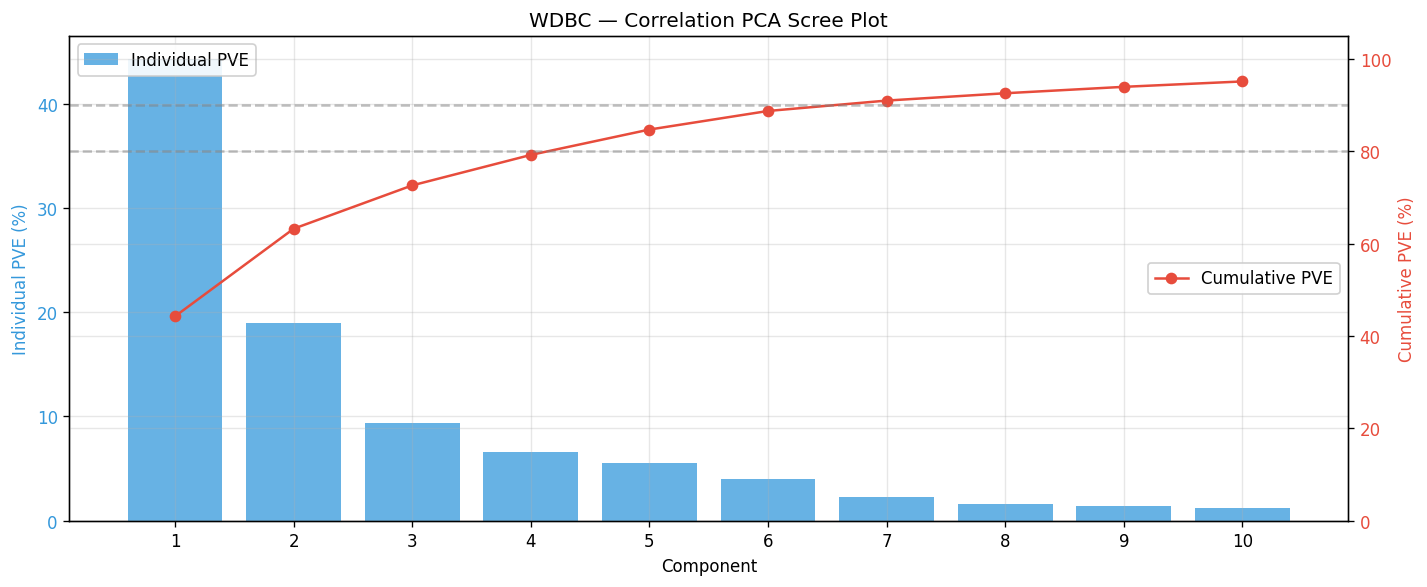

In [34]:
plot_scree(pca_wdbc_cor, n_components=N_COMPONENTS, title='WDBC — Correlation PCA Scree Plot')
plt.show()

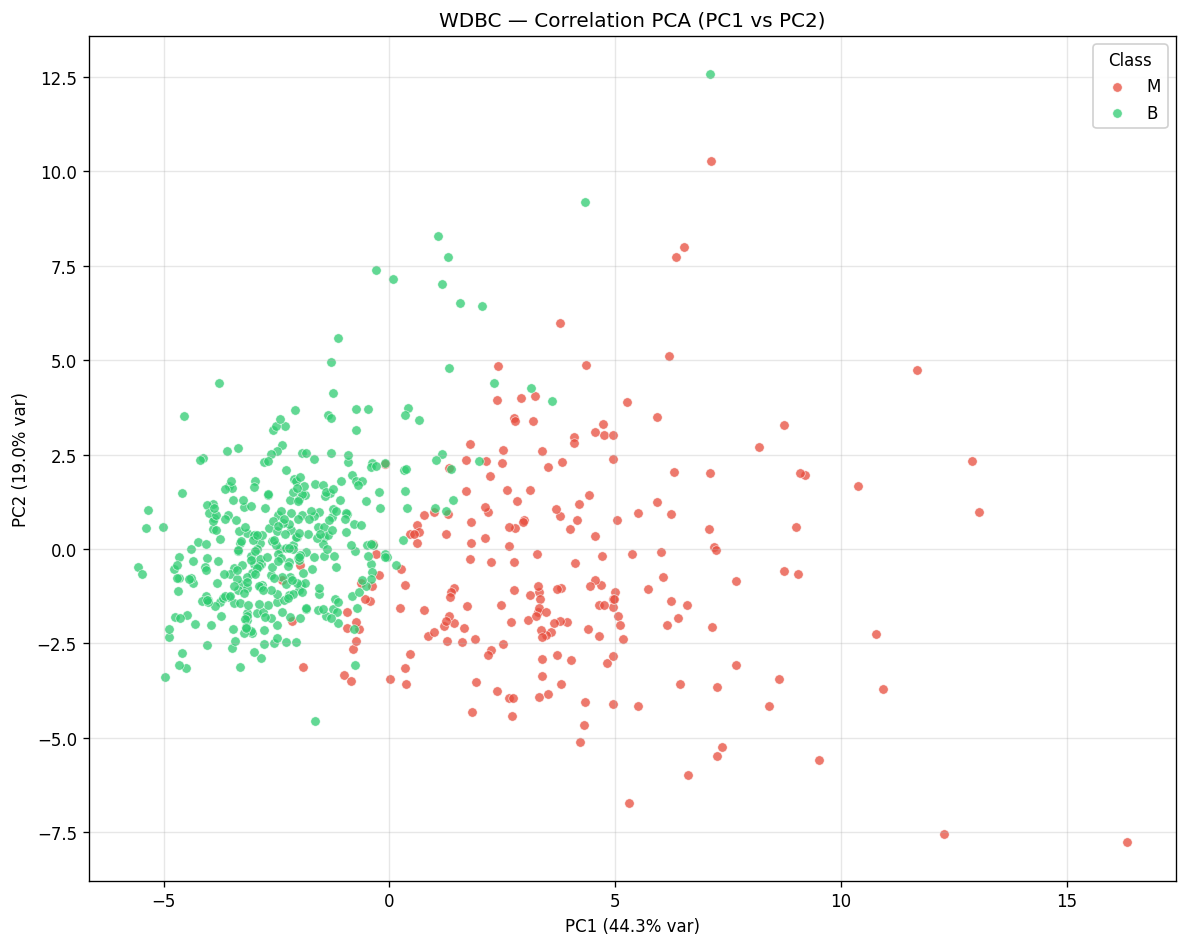

In [35]:
plot_pca_2d(scores_wdbc_cor, y_wdbc, WDBC_COLORS,
            title='WDBC — Correlation PCA (PC1 vs PC2)',
            pc_x=1, pc_y=2, pve=pve_wdbc_cor)
plt.show()

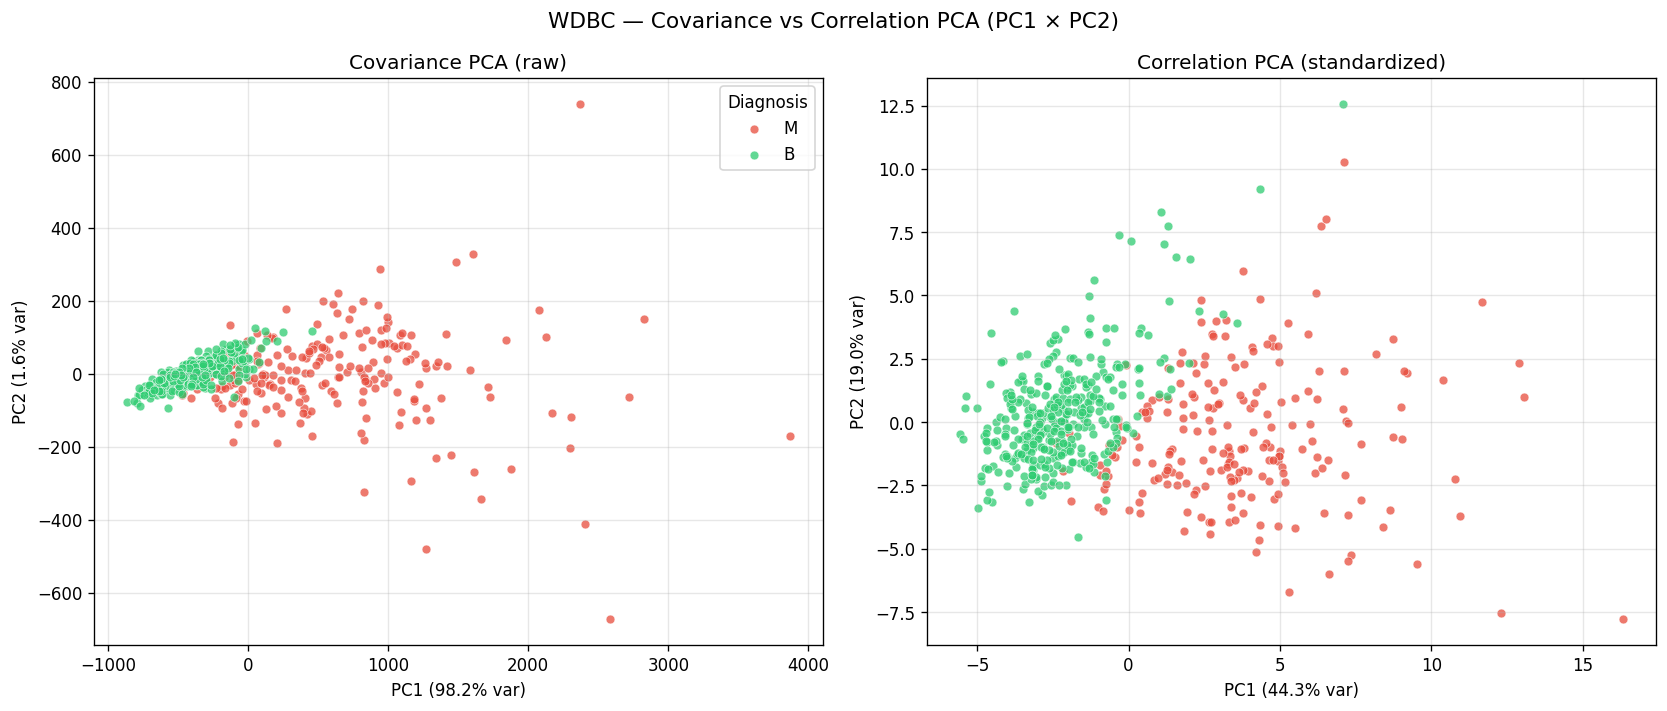

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, scores, pve, name in zip(
    axes,
    [scores_wdbc_cov, scores_wdbc_cor],
    [pve_wdbc_cov, pve_wdbc_cor],
    ['Covariance PCA (raw)', 'Correlation PCA (standardized)'],
):
    for cls, color in WDBC_COLORS.items():
        mask = y_wdbc == cls
        ax.scatter(scores[mask, 0], scores[mask, 1],
                   c=color, label=cls, alpha=0.75, s=28,
                   edgecolor='white', linewidth=0.4)
    ax.set_xlabel(f'PC1 ({pve[0] * 100:.1f}% var)')
    ax.set_ylabel(f'PC2 ({pve[1] * 100:.1f}% var)')
    ax.set_title(name)
axes[0].legend(title='Diagnosis')
fig.suptitle('WDBC — Covariance vs Correlation PCA (PC1 × PC2)', fontsize=13)
fig.tight_layout()
plt.show()

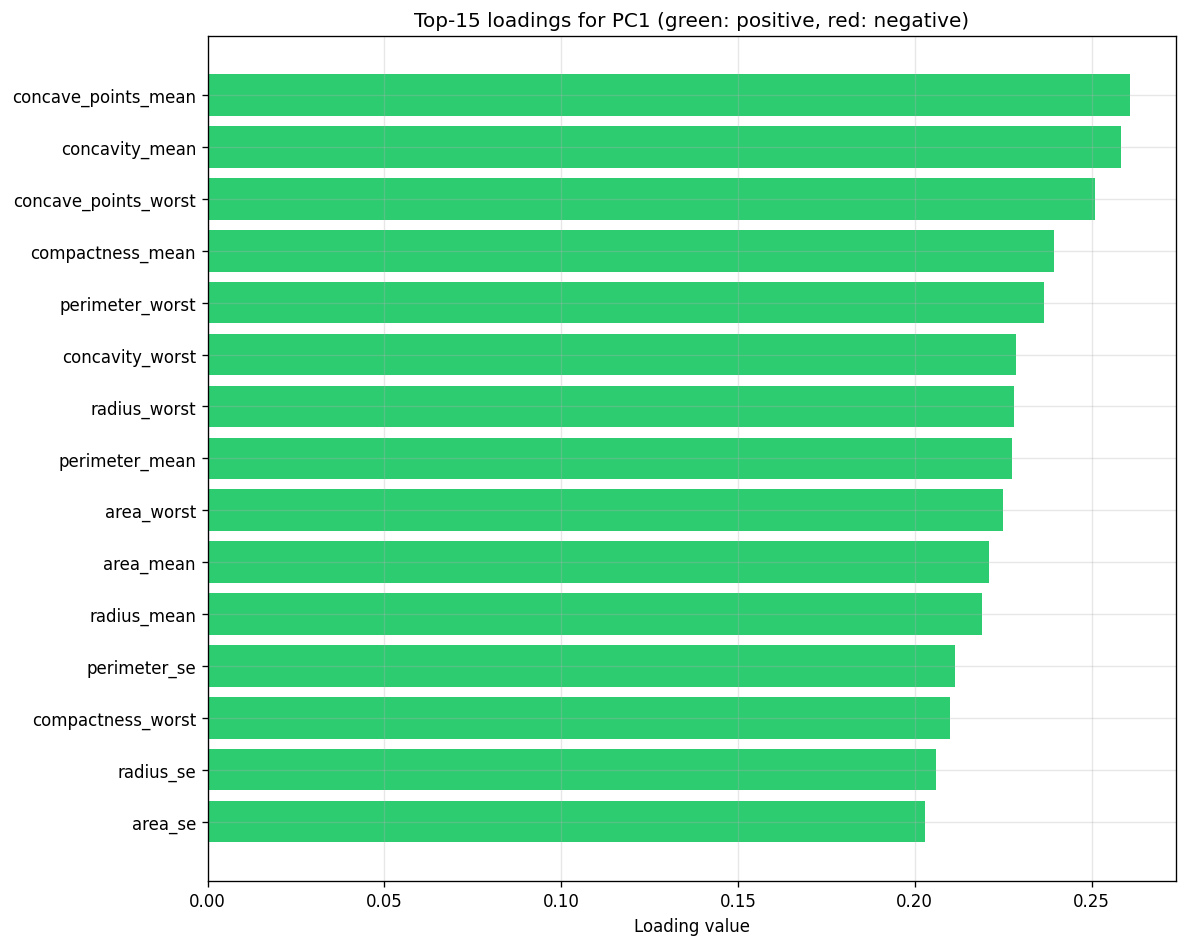

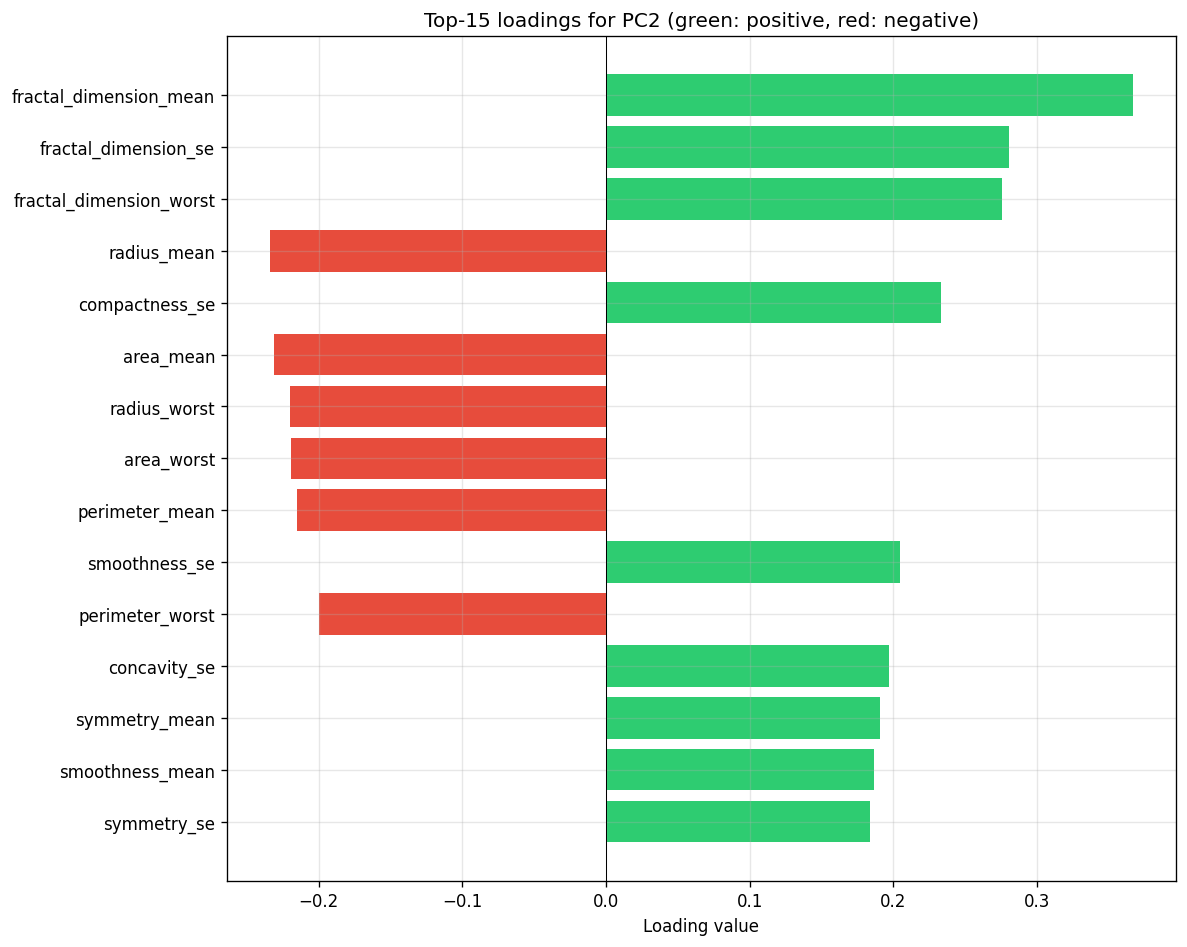

In [37]:
plot_loadings(pca_wdbc_cor.components_, feature_names_wdbc, pc_index=1, top_n=15)
plt.show()

plot_loadings(pca_wdbc_cor.components_, feature_names_wdbc, pc_index=2, top_n=15)
plt.show()

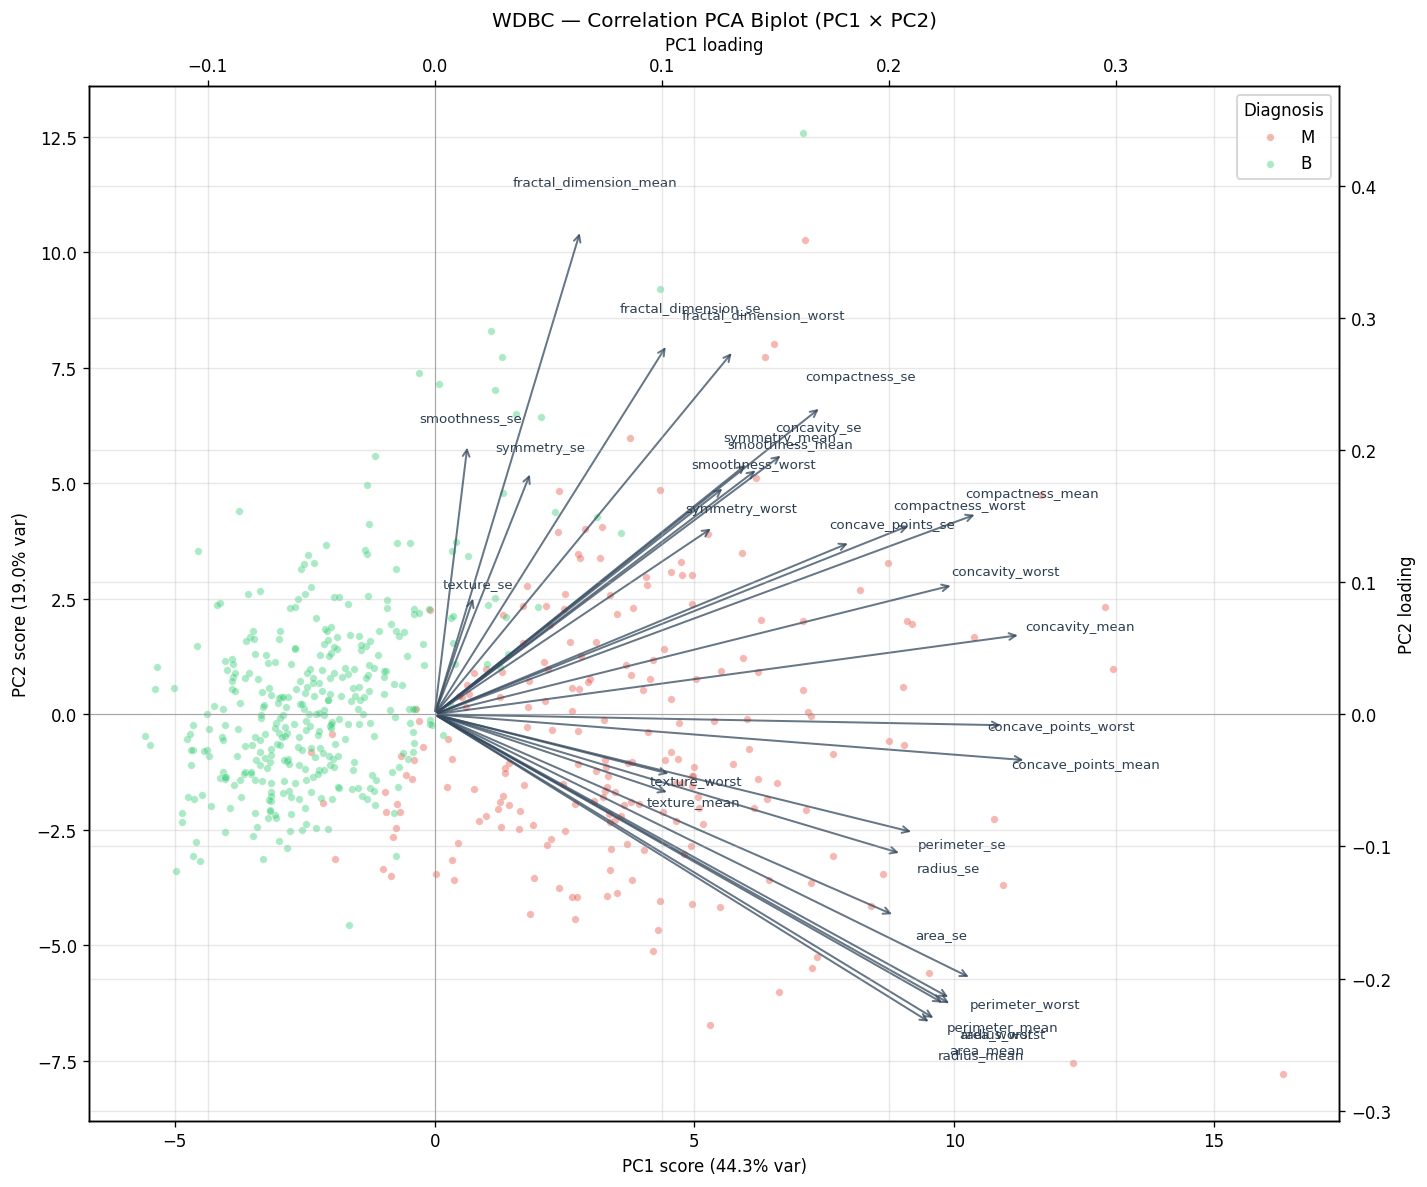

In [38]:
arrow_scale = 3.0
score_pc1 = scores_wdbc_cor[:, 0]
score_pc2 = scores_wdbc_cor[:, 1]
max_score_range = max(score_pc1.max() - score_pc1.min(),
                      score_pc2.max() - score_pc2.min())
loadings_pc1 = pca_wdbc_cor.components_[0]
loadings_pc2 = pca_wdbc_cor.components_[1]
scale_x = arrow_scale * np.sqrt(pve_wdbc_cor[0]) * max_score_range
scale_y = arrow_scale * np.sqrt(pve_wdbc_cor[1]) * max_score_range

fig, ax_scores = plt.subplots(figsize=(12, 10))
for cls, color in WDBC_COLORS.items():
    mask = y_wdbc == cls
    ax_scores.scatter(score_pc1[mask], score_pc2[mask],
                      c=color, label=cls, alpha=0.4, s=20,
                      edgecolor='white', linewidth=0.3)

for j, name in enumerate(feature_names_wdbc):
    dx = loadings_pc1[j] * scale_x
    dy = loadings_pc2[j] * scale_y
    ax_scores.annotate('', xy=(dx, dy), xytext=(0, 0),
                       arrowprops=dict(arrowstyle='->', color='#34495E',
                                       lw=1.2, alpha=0.75))
    ax_scores.text(dx * 1.10, dy * 1.10, name, fontsize=8,
                   color='#2C3E50', ha='center', va='center')

ax_scores.axhline(0, color='gray', lw=0.4)
ax_scores.axvline(0, color='gray', lw=0.4)
ax_scores.set_xlabel(f'PC1 score ({pve_wdbc_cor[0] * 100:.1f}% var)')
ax_scores.set_ylabel(f'PC2 score ({pve_wdbc_cor[1] * 100:.1f}% var)')
ax_scores.set_title('WDBC — Correlation PCA Biplot (PC1 × PC2)')
ax_scores.legend(title='Diagnosis', loc='upper right', framealpha=0.9)

xlim = ax_scores.get_xlim()
ylim = ax_scores.get_ylim()
ax_loadings_x = ax_scores.twiny()
ax_loadings_x.set_xlim(xlim[0] / scale_x, xlim[1] / scale_x)
ax_loadings_x.set_xlabel('PC1 loading')
ax_loadings_y = ax_scores.twinx()
ax_loadings_y.set_ylim(ylim[0] / scale_y, ylim[1] / scale_y)
ax_loadings_y.set_ylabel('PC2 loading')

fig.tight_layout()
plt.show()


**Biplot Yorumu.** Biplot, gözlemleri (Score'lar — noktalar) ve özellikleri (Loading'ler — oklar) **aynı PC1 × PC2 düzleminde** birleştiren standart bir PCA görselleştirmesidir. Alt/sol ekseni Score'ları orijinal birimlerde, üst/sağ ekseni ise Loading'leri $[-1, 1]$ aralığında okutmaktadır. Yorumlama anahtarları:

- **Ok uzunluğu.** Bir özelliğin PC1 × PC2 düzleminde ne kadar varyans katkısı yaptığını gösterir; daha uzun oklar (`*_worst` ile `radius/perimeter/area_*` aileleri) PC eksenlerine daha güçlü katkı verir, kısa oklar bu iki bileşene marjinal katkıda bulunur.
- **Ok yönü.** Özelliğin yüksek değerlerinin PC düzleminde hangi yönde uzandığını söyler. **Aynı yöne** işaret eden oklar pozitif korele özelliklerdir (örneğin `radius_mean`, `perimeter_mean`, `area_mean` neredeyse paralel uzanır — beklenildiği gibi, çünkü matematiksel olarak da bağlıdırlar); **zıt yönde** oklar negatif korele, **dik açıdaki** oklar ise yaklaşık ilişkisizdir.
- **Nokta–ok hizalanması.** Bir gözlem bulutu hangi okların yönüne yatkın yerleşmişse, o özellikler bakımından yüksek değer taşır. Malign (kırmızı) örnekler `*_worst` ve büyüklük oklarının yönünde toplanmakta; bu, bir önceki adımdaki Cohen's $d$ analizi ile tutarlıdır — sınıf ayrımının taşıyıcısı bu özellik aileleridir.

Biplot bu nedenle "PC eksenleri biyolojik olarak ne anlama geliyor?" sorusunu **görsel olarak** yanıtlayan en doğrudan araçtır; Loading bar chart'ları kadar sayısaldır ancak özellikler arası mekânsal ilişkiyi de korur.


**Yorum.**

- **Covariance PCA** üzerinde PC1 tek başına varyansın **~%98**'ini açıklıyor — fakat bu yanıltıcıdır: PC1 neredeyse tamamen `area_*` özellikleri tarafından domine edilmiştir (büyük ölçek, büyük varyans). Görselde sınıflar ayrışıyor görünse de bu, sadece `area`'nın tek başına M-B ayrımı yapması anlamına gelir. PCA'nın "çoklu özellik kombinasyonu" üretme amacı baltalanmıştır.
- **Correlation PCA** üzerinde PC1 daha sağlıklı bir **~%44** varyans açıklar; PC1+PC2 toplam **~%63**'e ulaşır. Bu, 30 özelliği fazla kayıp olmadan 2-3 boyuta indirebileceğimizin göstergesidir.
- PC1 yüklemelerine bakıldığında **`*_worst` ve `*_mean` versiyonları yüksek pozitif katsayılarla** yer alır; `radius`, `perimeter`, `area`, `concave_points`, `concavity`, `compactness` ailesi PC1'i şekillendirir. Bu PC pratik olarak "tümörün genel büyüklüğü + morfolojik düzensizliği" eksenidir ve M-B ayrımının ana taşıyıcısıdır.
- PC2 yüklemelerine bakıldığında `texture_*` ve `smoothness_*` öne çıkar — bunlar büyüklükten bağımsız doku özellikleridir. PC2 "şekil pürüzü" eksenidir; M-B ayrımına ikincil katkıda bulunur.

Bu yorum, **PCA'nın temel ilkesi** olan ortogonalitenin nasıl pratik anlam ürettiğinin somut örneğidir: birinci eksen büyüklük/şiddet, ona dik ikinci eksen ise dokusal incelik. İki eksen birbirinden bağımsız biyolojik bilgi taşır.

## 4.4 — PCA + Sınıflandırma

TCGA'da yaptığımız gibi: standartlaştırılmış veri üzerinde ham KNN baseline'ı ile değişen $k$ değerlerinde PCA+KNN karşılaştırması. WDBC'de $p = 30$ olduğu için baseline'da bile boyut laneti hafiftir; PCA'nın katma değeri burada **varyans azaltma** değil, **özellikler arası multikolineariteyi kaldırma** olacaktır.

In [39]:
knn = KNeighborsClassifier(n_neighbors=5)
raw_scores_wdbc = cross_val_score(knn, X_wdbc_z, y_wdbc, cv=5, n_jobs=-1)
print(f'WDBC ham (standardized, 30 features) — KNN(k=5) 5-fold CV:')
print(f'  accuracy = {raw_scores_wdbc.mean():.4f} ± {raw_scores_wdbc.std():.4f}')

WDBC ham (standardized, 30 features) — KNN(k=5) 5-fold CV:
  accuracy = 0.9649 ± 0.0096


WDBC — KNN(k=5) 5-fold CV accuracy vs PCA bileşen sayısı:
n_components  accuracy_mean  accuracy_std
         raw       0.964850      0.009610
           2       0.940258      0.010167
           3       0.929700      0.025425
           5       0.950753      0.016431
           7       0.963080      0.011685
          10       0.961310      0.013229
          15       0.964850      0.009610
          20       0.964850      0.009610
          30       0.964850      0.009610


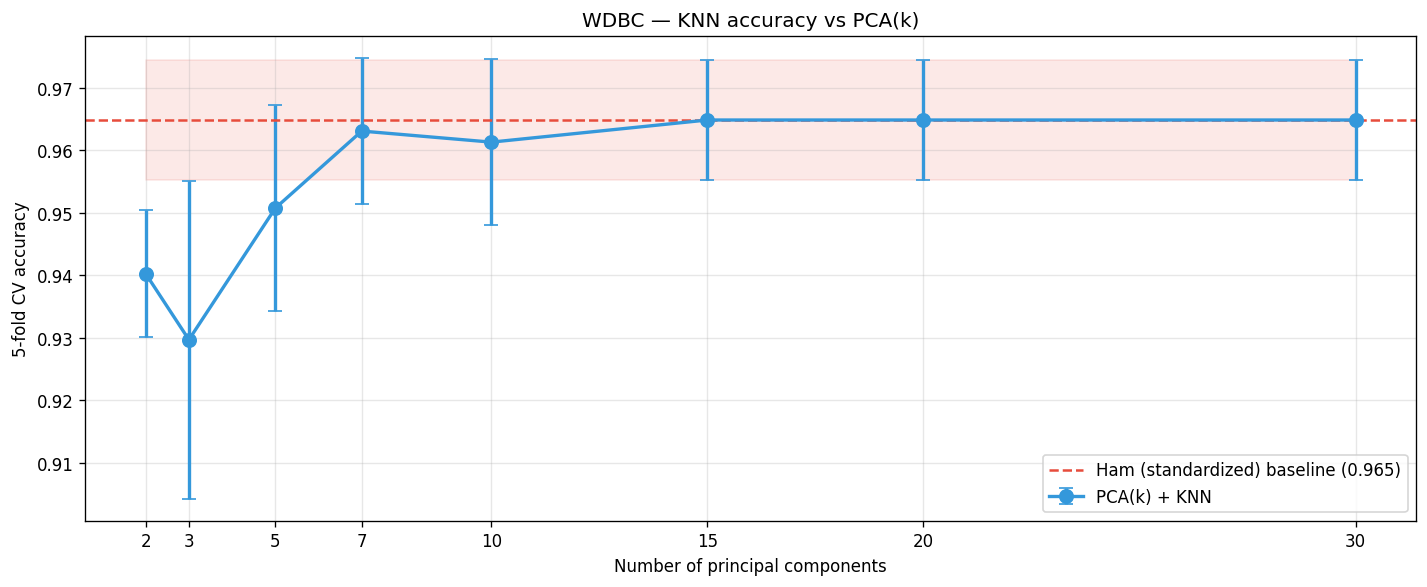


En iyi PCA(k): k = 15, accuracy = 0.9649


In [40]:
ks_wdbc = [2, 3, 5, 7, 10, 15, 20, 30]
knn_pca_wdbc_df = knn_accuracy_vs_components(
    X_wdbc_z, y_wdbc, ks=ks_wdbc, cv=5, n_neighbors=5, scale=False,
)

summary_wdbc_df = pd.concat([
    pd.DataFrame([{
        'n_components': 'raw',
        'accuracy_mean': raw_scores_wdbc.mean(),
        'accuracy_std': raw_scores_wdbc.std(),
    }]),
    knn_pca_wdbc_df,
], ignore_index=True)

print('WDBC — KNN(k=5) 5-fold CV accuracy vs PCA bileşen sayısı:')
print(summary_wdbc_df.to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 5))
ks_num = knn_pca_wdbc_df['n_components'].values
means = knn_pca_wdbc_df['accuracy_mean'].values
stds = knn_pca_wdbc_df['accuracy_std'].values
ax.errorbar(ks_num, means, yerr=stds, fmt='o-', color='#3498DB',
            capsize=4, lw=2, markersize=8, label='PCA(k) + KNN')
ax.axhline(raw_scores_wdbc.mean(), color='#E74C3C', ls='--',
           label=f'Ham (standardized) baseline ({raw_scores_wdbc.mean():.3f})')
ax.fill_between(ks_num,
                raw_scores_wdbc.mean() - raw_scores_wdbc.std(),
                raw_scores_wdbc.mean() + raw_scores_wdbc.std(),
                color='#E74C3C', alpha=0.12)
ax.set_xlabel('Number of principal components')
ax.set_ylabel('5-fold CV accuracy')
ax.set_title('WDBC — KNN accuracy vs PCA(k)')
ax.legend(loc='lower right')
ax.set_xticks(ks_num)
fig.tight_layout()
plt.show()

best_k_wdbc = int(knn_pca_wdbc_df.loc[knn_pca_wdbc_df['accuracy_mean'].idxmax(), 'n_components'])
best_acc_wdbc = knn_pca_wdbc_df['accuracy_mean'].max()
print(f'\nEn iyi PCA(k): k = {best_k_wdbc}, accuracy = {best_acc_wdbc:.4f}')

### Bölüm 4 Özeti

WDBC üzerinde PCA, TCGA'dakinden farklı bir rol üstlendi:

- 30 özellik **birkaç fazlalık adacık** halinde gruplanır (radius/perimeter/area; compactness/concavity/concave_points). PCA bu adacıkları az sayıda bağımsız "morfolojik konsept"e indirger.
- **Correlation PCA** burada açıkça daha iyi seçimdir; covariance PCA `area` ailesi tarafından domine edilir.
- PC1 "büyüklük/şiddet", PC2 "dokusal incelik" eksenleri olarak yorumlanabilir; PC1+PC2 toplam varyansın **~%63**'ünü açıklar.
- 2-3 component KNN için yeterlidir; daha fazla bileşen ek bilgi katmaz çünkü 30 özelliğin gerçek bilgi boyutu zaten 5-10 civarındadır.

# Bölüm 5 — Karşılaştırmalı Analiz: Genomik vs Klinik Veri

Bu bölüm projenin özgün katkısının kalbidir. Aynı algoritmayı (**PCA**) yapısal olarak **birbirine zıt** iki veri setinde uyguladık:

- **TCGA-PANCAN**: $p \gg n$ rejimi, 5 sınıf, RNA-seq verisi — sınıf imzaları binlerce genin küçük kombinasyonlarında.
- **WDBC**: $p \ll n$ rejimi, 2 sınıf, klinik morfoloji — sınıf farkları az sayıda kuvvetli özellikte konsantre.

Önce sayısal karşılaştırmayı oluşturup ardından üç teorik soruyu tartışacağız.

Karşılaştırma için TCGA üzerindeki temel sayıları (PVE, k=2 KNN accuracy, %90 PVE için gereken bileşen sayısı) bu notebook'ta yeniden hesaplıyoruz.

In [41]:
tcga_data = pd.read_csv(TCGA_DATA_PATH, index_col=0)
tcga_labels = pd.read_csv(TCGA_LABELS_PATH, index_col=0)
tcga_data = tcga_data.loc[tcga_labels.index]

gene_var = tcga_data.var(axis=0).values
X_tcga = tcga_data.values[:, gene_var > 0].astype(np.float64)
y_tcga = tcga_labels['Class'].values
print(f'TCGA filtered shape: {X_tcga.shape}')

pca_tcga_cov = PCA(n_components=50, random_state=RANDOM_STATE).fit(X_tcga)
pve_tcga_cov = pca_tcga_cov.explained_variance_ratio_
cum_pve_tcga_cov = np.cumsum(pve_tcga_cov)

X_tcga_z = StandardScaler().fit_transform(X_tcga)
pca_tcga_cor = PCA(n_components=50, random_state=RANDOM_STATE).fit(X_tcga_z)
pve_tcga_cor = pca_tcga_cor.explained_variance_ratio_
cum_pve_tcga_cor = np.cumsum(pve_tcga_cor)

scores_tcga_cov_k2 = pca_tcga_cov.transform(X_tcga)[:, :2]
scores_tcga_cor_k2 = pca_tcga_cor.transform(X_tcga_z)[:, :2]

acc_tcga_cov_k2 = cross_val_score(
    KNeighborsClassifier(n_neighbors=5), scores_tcga_cov_k2, y_tcga, cv=5, n_jobs=-1,
).mean()
acc_tcga_cor_k2 = cross_val_score(
    KNeighborsClassifier(n_neighbors=5), scores_tcga_cor_k2, y_tcga, cv=5, n_jobs=-1,
).mean()

def k_for_pve(cum, thr):
    return int(np.argmax(cum >= thr) + 1) if (cum >= thr).any() else None

k90_tcga_cov = k_for_pve(cum_pve_tcga_cov, 0.90)
k90_tcga_cor = k_for_pve(cum_pve_tcga_cor, 0.90)
k90_wdbc_cov = k_for_pve(cum_pve_wdbc_cov, 0.90)
k90_wdbc_cor = k_for_pve(cum_pve_wdbc_cor, 0.90)

print(f'TCGA k(>=90% PVE, cov): {k90_tcga_cov}, (cor): {k90_tcga_cor}')
print(f'WDBC k(>=90% PVE, cov): {k90_wdbc_cov}, (cor): {k90_wdbc_cor}')

TCGA filtered shape: (801, 20264)
TCGA k(>=90% PVE, cov): None, (cor): None
WDBC k(>=90% PVE, cov): 1, (cor): 7


In [42]:
scores_wdbc_cov_k2 = pca_wdbc_cov.transform(X_wdbc)[:, :2]
scores_wdbc_cor_k2 = pca_wdbc_cor.transform(X_wdbc_z)[:, :2]

acc_wdbc_cov_k2 = cross_val_score(
    KNeighborsClassifier(n_neighbors=5), scores_wdbc_cov_k2, y_wdbc, cv=5, n_jobs=-1,
).mean()
acc_wdbc_cor_k2 = cross_val_score(
    KNeighborsClassifier(n_neighbors=5), scores_wdbc_cor_k2, y_wdbc, cv=5, n_jobs=-1,
).mean()

print(f'WDBC PCA(k=2) KNN — cov: {acc_wdbc_cov_k2:.4f}, cor: {acc_wdbc_cor_k2:.4f}')
print(f'TCGA PCA(k=2) KNN — cov: {acc_tcga_cov_k2:.4f}, cor: {acc_tcga_cor_k2:.4f}')

WDBC PCA(k=2) KNN — cov: 0.9227, cor: 0.9403
TCGA PCA(k=2) KNN — cov: 0.9538, cor: 0.6716


In [43]:
comparison = pd.DataFrame(
    {
        'TCGA-PANCAN': [
            X_tcga.shape[0],
            X_tcga.shape[1],
            len(np.unique(y_tcga)),
            'RNA-seq (log-normalized)',
            f'{k90_tcga_cov} (cov) / {k90_tcga_cor} (cor)',
            f'{pve_tcga_cov[0] * 100:.2f}% (cov)',
            f'{(pve_tcga_cov[0] + pve_tcga_cov[1]) * 100:.2f}% (cov)',
            f'{acc_tcga_cov_k2:.4f}',
        ],
        'WDBC': [
            X_wdbc.shape[0],
            X_wdbc.shape[1],
            len(np.unique(y_wdbc)),
            'Cell morphology',
            f'{k90_wdbc_cov} (cov) / {k90_wdbc_cor} (cor)',
            f'{pve_wdbc_cor[0] * 100:.2f}% (cor)',
            f'{(pve_wdbc_cor[0] + pve_wdbc_cor[1]) * 100:.2f}% (cor)',
            f'{acc_wdbc_cor_k2:.4f}',
        ],
    },
    index=[
        'n (örnek)',
        'p (özellik)',
        'Sınıf sayısı',
        'Veri türü',
        '%90 PVE için PC sayısı',
        'PC1 PVE',
        'PC1+PC2 PVE',
        'PCA(k=2) + KNN accuracy',
    ],
)
comparison

,TCGA-PANCAN,WDBC
n (örnek),801,569
p (özellik),20264,30
Sınıf sayısı,5,2
Veri türü,RNA-seq (log-normalized),Cell morphology
%90 PVE için PC sayısı,None (cov) / None (cor),1 (cov) / 7 (cor)
PC1 PVE,15.84% (cov),44.27% (cor)
PC1+PC2 PVE,26.34% (cov),63.24% (cor)
PCA(k=2) + KNN accuracy,0.9538,0.9403


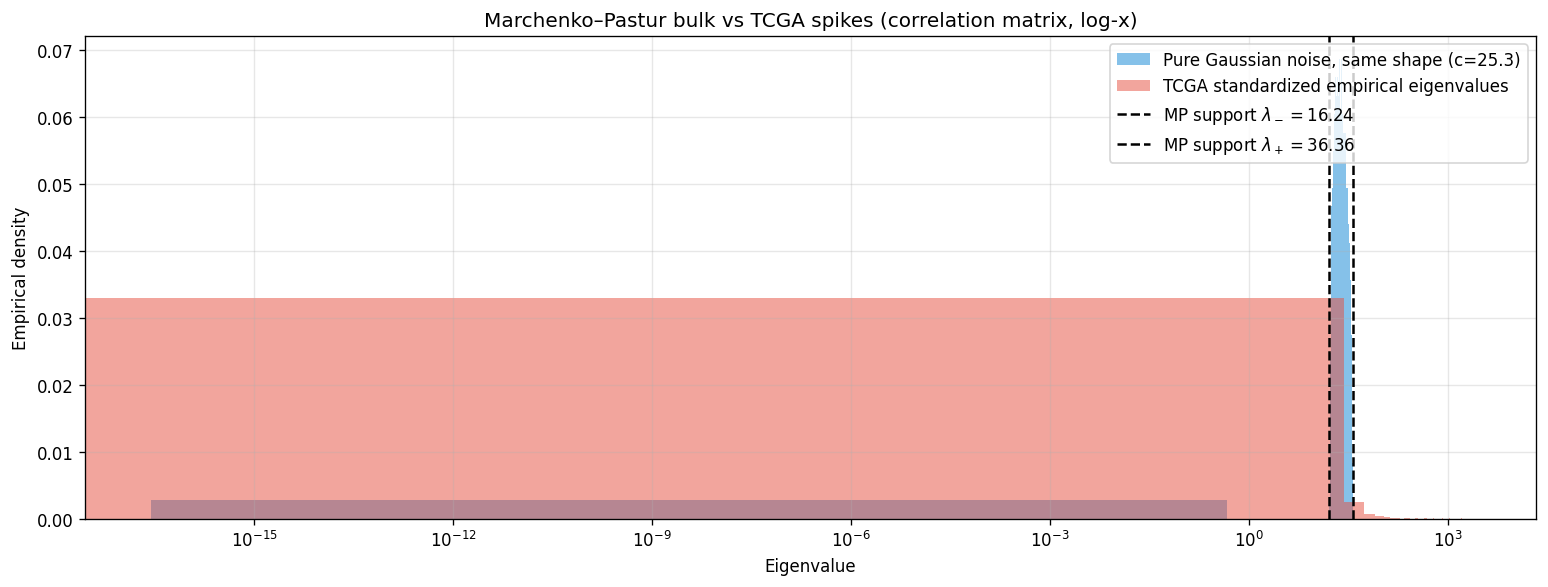

TCGA eigenvalue'larından MP üst sınırının üzerinde olanlar (signal spikes): 68
Bunlar PCA'nın yakaladığı gerçek biyolojik sinyalin component sayısıdır.


In [44]:
def empirical_eigvals_via_gram(X):
    """Return non-zero eigenvalues of (1/(n-1)) X^T X using the Gram-matrix trick."""
    X_c = X - X.mean(axis=0)
    K = (X_c @ X_c.T) / (X.shape[0] - 1)
    return np.sort(np.linalg.eigvalsh(K))[::-1]

rng_mp = np.random.default_rng(RANDOM_STATE)
n_noise = X_tcga.shape[0]
p_noise = X_tcga.shape[1]
c_ratio = p_noise / n_noise
lam_minus = (1 - np.sqrt(c_ratio)) ** 2
lam_plus = (1 + np.sqrt(c_ratio)) ** 2

X_noise = rng_mp.standard_normal((n_noise, p_noise))
eig_noise = empirical_eigvals_via_gram(X_noise)
eig_tcga = empirical_eigvals_via_gram(X_tcga_z)

fig, ax = plt.subplots(figsize=(13, 5))
ax.hist(eig_noise, bins=80, density=True, color='#3498DB', alpha=0.6,
        label=f'Pure Gaussian noise, same shape (c={c_ratio:.1f})')
ax.hist(eig_tcga, bins=80, density=True, color='#E74C3C', alpha=0.5,
        label='TCGA standardized empirical eigenvalues')
ax.axvline(lam_minus, color='black', ls='--', label=fr'MP support $\lambda_-={lam_minus:.2f}$')
ax.axvline(lam_plus, color='black', ls='--', label=fr'MP support $\lambda_+={lam_plus:.2f}$')
ax.set_xlabel('Eigenvalue')
ax.set_ylabel('Empirical density')
ax.set_title('Marchenko–Pastur bulk vs TCGA spikes (correlation matrix, log-x)')
ax.set_xscale('log')
ax.legend(loc='upper right')
fig.tight_layout()
plt.show()

n_spikes = int((eig_tcga > lam_plus).sum())
print(f'TCGA eigenvalue\'larından MP üst sınırının üzerinde olanlar (signal spikes): {n_spikes}')
print(f'Bunlar PCA\'nın yakaladığı gerçek biyolojik sinyalin component sayısıdır.')

Mavi histogram (saf Gauss gürültü) $[\lambda_-, \lambda_+]$ MP-bulk içinde toplanır. Kırmızı histogram (gerçek TCGA) aynı bulk'a sahiptir — **çünkü 20.000 genin çoğu sınıf imzasıyla ilgisizdir, sadece gürültüye katkıda bulunur** — ama bunun *üstüne*, $\lambda_+$'ı çok aşan sağ kuyruk eigenvalue'lar eklenmiştir. **Bu spike'lar gerçek biyolojik sinyali taşır** ve PCA'nın yakaladığı düşük-boyutlu yapıdır. Spike sayısı genellikle gerçek alt grup sayısı + birkaç ek faktör mertebesindedir.

### Yorum

1. **TCGA için covariance kazanır.** Gen ekspresyon değerleri zaten aynı birimde (log-RNA-seq) ölçülmüştür ve gen-spesifik varyans **biyolojik bilgi taşır**: yüksek varyanslı genler doğrudan kanser tipini ayıran marker'lardır. Standardize edersek bu marker'ları silikleştiririz; sonuç olarak PC1 daha az bilgi yakalar ve aynı PVE seviyesine ulaşmak için daha fazla bileşen gerekir.
2. **WDBC için correlation kazanır.** 30 özellik tamamen farklı birimlerdedir: `area_mean` $\in [143, 2501]$ mm², `smoothness_mean` $\in [0.05, 0.16]$ adımsızdır. Covariance PCA'da `area_*` ailesi tek başına PC1'in **~%98**'ini domine eder — bu PCA'nın amacını boşa çıkarır çünkü 30 özellikten biri zaten yeterli olurdu. Correlation PCA bu ölçek farklılığını eşitleyip gerçek **multikolineariteyi çözer**.

### Karar Kuralı (özet)

- **Özellikler homojen ve birimde tutarlı** + **varyans biyolojik bilgi** → **Covariance PCA** (örn. gene expression, image pixels, sensor readings of same modality).
- **Özellikler heterojen, farklı birimlerde** ya da **özelliklerin varyansları rastlantısal/biçimseldir** → **Correlation PCA** (örn. klinik özellikler, mali oranlar, anket skorları).

Yani "Covariance daha iyidir" ya da "Correlation daha iyidir" tek başına yanlış bir genellemedir; doğru karar veri setinin **semantik yapısına** bağlıdır.